# 06 — Graph-Based Pseudotime of Ductal Niche Evolution in PDAC (Sample 34434_1)

## Scientific context

Pancreatic ductal adenocarcinoma (PDAC) does not progress as a uniform disease. Within a single tumour section, ductal structures exist in a spectrum of states: from well-organised, differentiated ducts resembling normal pancreatic epithelium, through PanIN-like dysplastic intermediates, to invasive glands embedded in dense desmoplastic stroma. Capturing this continuum — and mapping which aspects of the microenvironment co-evolve with it — is central to understanding PDAC biology.

**Sample 34434_1** is a PDAC tissue section with three anatomically distinct regions:
- **Left/centre** — invasive tumour ducts infiltrating into the adjacent duodenum
- **Stromal core** — dense desmoplastic stroma with reactive fibroblasts (CAFs) surrounding tumour nests
- **Right** — residual normal pancreatic tissue, providing an internal spatial reference for the "pre-malignant" end of the continuum

This notebook reconstructs the **ductal niche trajectory** within this section: each ductal connected component (gland) is characterised as a multi-dimensional feature vector encoding morphology, graph topology, cellular state heterogeneity, and the surrounding immune/stromal microenvironment. ElPiGraph then fits a principal tree through this feature space, yielding a pseudotime axis that captures the continuous spectrum of niche states. Crucially, because pseudotime is derived from niche-level features — not individual cell expression — it reflects the collective, spatially coherent organisation of each gland.

## What this analysis reveals

1. **Which gland-level features drive the niche trajectory** — morphology, organisation, proliferation, and desmoplastic context
2. **How the surrounding microenvironment co-evolves** — fibroblast activation (FAP, aSMA), immune infiltration (T cell subtypes, B cells), and stromal composition along pseudotime
3. **Whether the trajectory branches** — representing distinct routes of progression (e.g. a proliferative vs a dedifferentiated invasive arm)
4. **Which direct cell-cell interactions change** — the dynamic proximity of immune and stromal cells to ductal epithelium as niches progress

## Data requirements
- `data/exp_2/34434_1_adata.h5ad` — AnnData with cells × markers
- `data/exp_2/34434_1_annotation.csv` — Tier A (broad) and Tier B (fine-grained) phenotype labels
- `data/exp_2/pixel_features.csv` — morphology and texture features per cell
- `data/exp_2/segmentation/` — per-FOV segmentation masks for ductal niche identification

**Run order:** Execute cells top-to-bottom in the `spatioev_env` conda environment.

In [1]:
from pathlib import Path  # needed before config is loaded
import os

# DATA AVAILABILITY CHECK
# Experiment 2 requires the following files
_data_dir = Path("/Users/shihongwu/SpatioEv") / "data" / "exp_2"
_required_files = [
    _data_dir / "34434_1_adata.h5ad",
    _data_dir / "34434_1_annotation.csv",
    _data_dir / "pixel_features.csv",
]
_missing = [f for f in _required_files if not os.path.exists(f)]
if _missing:
    print(f'Missing required data files: {_missing}')
    print('   This notebook requires real experimental data to run.')
    print('   The code is shown for reference.')
else:
    print('All required data files found. Notebook is ready to run.')


All required data files found. Notebook is ready to run.


## Workflow overview

The analysis proceeds in seven stages, each building on the previous:

| Stage | Step | Key output |
|---|---|---|
| 1 | Load data and phenotypes | AnnData with Tier A/B labels and pixel features |
| 2 | Identify ductal niche components | Per-gland component IDs via segmentation mask adjacency |
| 3 | Build cell graph + niche feature table | Per-niche morphology, topology, state, and surroundings |
| 4 | Score PDAC pathology modules | Interpretable biological axes per niche |
| 5 | Prepare pseudotime feature matrix | Filtered, balanced feature set for trajectory |
| 6 | ElPiGraph trajectory + pseudotime | Niche pseudotime, branch labels, UMAP visualisation |
| 7 | Surrounding context + interaction dynamics | How the TME co-evolves with the niche state |

The unit of analysis is the **ductal niche** (a spatially connected group of ductal epithelial cells forming a gland), not the individual cell. This niche-level abstraction is biologically motivated: PDAC progression involves collective, coordinated changes in gland architecture rather than cell-autonomous changes. Pseudotime is then propagated back to individual cells for spatial visualisation.

In [2]:
%matplotlib inline

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import spatioev as sv
from spatioev.tl import (
    add_branch_time_bins,
    block_balance_feature_matrix,
    branch_time_feature_matrix,
    compute_feature_trend_table,
    find_branch_transition_features,
    infer_branch_labels,
    node_graph,
    prepare_pseudotime_feature_matrix,
    project_tree_nodes_to_embedding,
    summarize_branches,
    tree_edges,
)

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})
# ── Nature/Cell publication rcParams ─────────────────────────────────────────
import matplotlib as mpl
_pub_rc = {
    "font.family":       "sans-serif",
    "font.sans-serif":   ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":         7,
    "axes.titlesize":    8,
    "axes.labelsize":    7,
    "xtick.labelsize":   6,
    "ytick.labelsize":   6,
    "legend.fontsize":   6,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size":  2.5,
    "ytick.major.size":  2.5,
    "lines.linewidth":   1.0,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.facecolor":    "white",
    "figure.facecolor":  "white",
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
}
mpl.rcParams.update(_pub_rc)


## Configuration

The notebook writes derived tables into `notebooks/results/pseudotime_exp2/`, which is ignored by Git. Large local input data stay in `data/exp_2/` and are also ignored for repository upload.

In [3]:
ROOT = Path("/Users/shihongwu/SpatioEv")
if not (ROOT / "spatioev").exists():
    ROOT = Path.cwd()
    if not (ROOT / "spatioev").exists():
        for candidate in ROOT.parents:
            if (candidate / "spatioev").exists():
                ROOT = candidate
                break

os.chdir(ROOT)

DATA_DIR = ROOT / "data" / "exp_2"
RESULT_DIR = ROOT / "notebooks" / "results" / "pseudotime_exp2"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

ADATA_PATH = DATA_DIR / "34434_1_adata.h5ad"
ANNOTATION_PATH = DATA_DIR / "34434_1_annotation.csv"
PIXEL_FEATURE_PATH = DATA_DIR / "pixel_features.csv"
SEGMENTATION_DIR = DATA_DIR / "segmentation"
LEGACY_NICHE_FEATURE_CACHE = DATA_DIR / "niche_feature_table.csv"
NICHE_FEATURE_CACHE = RESULT_DIR / "niche_feature_table.csv"

PIXEL_SIZE_UM = 0.325
DUCT_LABEL = "pancreatic ductal epithelium"
DUCT_NICHE_KEY = "pancreatic ductal epithelium_mask_component"
RECOMPUTE_NICHE_FEATURES = False

print(f"Working directory: {ROOT}")
print(f"Result directory: {RESULT_DIR}")

Working directory: /Users/shihongwu/SpatioEv
Result directory: /Users/shihongwu/SpatioEv/paper/notebooks/results/pseudotime_exp2


## Small Notebook Utilities

These utilities are kept local because they only control plotting and notebook display. Analysis logic is handled by SpatioEv modules.

In [4]:
def present(columns, candidates):
    """Return candidate columns that are present."""
    return [col for col in candidates if col in columns]


def safe_label(value):
    return str(value).replace(" ", "_").replace("/", "_").replace("+", "")


def surround_marker_col(phenotype_label, marker_name, stat="mean"):
    return f"surround__{safe_label(phenotype_label)}__{marker_name}__{stat}"


def plot_continuous_spatial(
    obs,
    value_col,
    title=None,
    x_col="X_centroid",
    y_col="Y_centroid",
    background_mask=None,
    cmap="viridis",
    point_size=0.25,
    figsize=(8, 8),
):
    fig, ax = plt.subplots(figsize=figsize)
    if background_mask is not None and background_mask.any():
        ax.scatter(
            obs.loc[background_mask, x_col],
            obs.loc[background_mask, y_col],
            color="lightgray",
            s=point_size,
            alpha=0.45,
            linewidths=0,
        )
    mask = obs[value_col].notna() if background_mask is None else ~background_mask
    sc = ax.scatter(
        obs.loc[mask, x_col],
        obs.loc[mask, y_col],
        c=pd.to_numeric(obs.loc[mask, value_col], errors="coerce"),
        cmap=cmap,
        s=point_size,
        alpha=1,
        linewidths=0,
    )
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.colorbar(sc, ax=ax, label=value_col)
    if title:
        ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_lowess_feature_map(
    df,
    feature_map,
    pseudotime_col="elpigraph_pseudotime",
    frac=0.3,
    min_points=15,
    figsize=(5.0, 3.5),
    title=None,
    ylabel="Value",
    ylim=None,
    legend_loc="best",
    legend_bbox=None,
):
    import statsmodels.api as sm

    feature_map = {feature: spec for feature, spec in feature_map.items() if feature in df.columns}
    if not feature_map:
        print("No matching features available to plot.")
        return pd.DataFrame(columns=["feature", "label"])

    fig, ax = plt.subplots(figsize=figsize)
    plotted = []
    for feature, (label, color) in feature_map.items():
        tmp = df[[pseudotime_col, feature]].dropna().sort_values(pseudotime_col)
        if len(tmp) < min_points:
            continue
        lowess = sm.nonparametric.lowess(
            tmp[feature],
            tmp[pseudotime_col],
            frac=frac,
            return_sorted=True,
        )
        ax.plot(lowess[:, 0], lowess[:, 1], color=color, linewidth=1.8, label=label)
        plotted.append({"feature": feature, "label": label})

    if not plotted:
        plt.close(fig)
        print("No features had enough points to plot.")
        return pd.DataFrame(columns=["feature", "label"])

    ax.set_xlabel("Pseudotime")
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(False)
    if legend_bbox is None:
        ax.legend(frameon=False, fontsize=7, loc=legend_loc)
    else:
        ax.legend(frameon=False, fontsize=7, loc=legend_loc, bbox_to_anchor=legend_bbox)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(plotted)


## Load Sample and Annotations

In [5]:
adata = sv.load_h5ad(ADATA_PATH)

annotations = pd.read_csv(ANNOTATION_PATH, index_col=0)
annotation_cols = [col for col in ["Tier_A", "Tier_B"] if col in annotations.columns]
adata.obs = adata.obs.join(annotations[annotation_cols], how="left")

pixel_features = pd.read_csv(PIXEL_FEATURE_PATH)
obs_index_name = adata.obs.index.name or "cell_id"
adata.obs = (
    adata.obs.reset_index(names=obs_index_name)
    .merge(pixel_features, on=["label", "fov"], how="left")
    .set_index(obs_index_name)
)
adata.obs_names_make_unique()

pixel_cols = [col for col in pixel_features.columns if col not in {"label", "fov"}]
valid_pixel_mask = adata.obs[pixel_cols].notna().all(axis=1)
print(f"Keeping {valid_pixel_mask.sum()} / {len(valid_pixel_mask)} cells after requiring pixel features.")
adata = adata[valid_pixel_mask].copy()

adata

Keeping 1763634 / 1766481 cells after requiring pixel features.


AnnData object with n_obs × n_vars = 1763634 × 37
    obs: 'label', 'area', 'eccentricity', 'major_axis_length', 'minor_axis_length', 'perimeter', 'convex_area', 'equivalent_diameter', 'orientation', 'solidity', 'feret_diameter_max', 'Y_centroid', 'X_centroid', 'major_minor_axis_ratio', 'perim_square_over_area', 'major_axis_equiv_diam_ratio', 'convex_hull_resid', 'centroid_dif', 'num_concavities', 'circularity', 'fractual_dimension', 'boundary_irregularity', 'nc_ratio', 'cell_size_nuclear', 'CD11b_nuclear', 'CD19_nuclear', 'CD20_nuclear', 'CD27_nuclear', 'CD3_nuclear', 'CD31_nuclear', 'CD38_nuclear', 'CD4_nuclear', 'CD4_2_nuclear', 'CD56_nuclear', 'CD8_nuclear', 'CD8_2_nuclear', 'CK19_nuclear', 'COL3_nuclear', 'CXCL13_nuclear', 'CXCR5_nuclear', 'DNA_1_nuclear', 'FAP_nuclear', 'FOXP3_nuclear', 'FOXP3_2_nuclear', 'GATA3_nuclear', 'GranzymeB_nuclear', 'HLADR_nuclear', 'IgA_nuclear', 'IgM_nuclear', 'Ki67_nuclear', 'MERTK_nuclear', 'NaKATPase_nuclear', 'PCK_nuclear', 'PDGFRa_nuclear', 'PDL1

## Phenotype Overview

Before trajectory inference, inspect the cell phenotyping layers used to define the ductal niche and its surrounding microenvironment.

**What to look for in this sample (34434_1):**
- **Tier A** (broad phenotypes): Confirm that `pancreatic ductal epithelium` cells occupy distinct spatial regions — invasive gland clusters on the left/centre and more regular ductal structures on the right. `Fibroblasts` should form an enveloping pattern around ductal nests (desmoplastic stroma). `T cells` and `B lineage` should be visible at the tumour-stroma interface and in potential TLS clusters.
- **Tier B** (fine-grained): Look for heterogeneity within the fibroblast compartment (activated vs quiescent CAF subsets) and within the immune compartment (cytotoxic vs regulatory T cells, plasmablast-like B cells).

The spatial distribution of phenotypes at this stage guides interpretation of all subsequent trajectory analyses: pseudotime "early" should map to the right (normal pancreas region), and "late" should concentrate in the invasive left/centre.

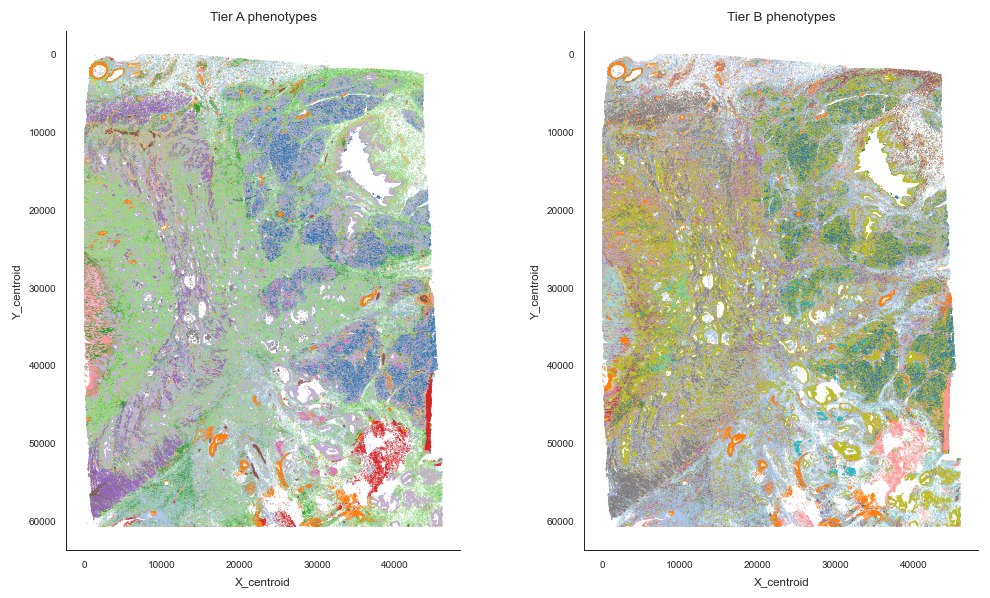

,Tier_A_count,Tier_B_count
Fibroblasts,447469.0,NaN
pancreatic ductal epithelium,423758.0,423758.0
Vimentin only mesenchyme,285379.0,285379.0
Endothelial cells,137447.0,137447.0
pancreatic acinar epithelium,124722.0,124722.0
T cells,106291.0,NaN
Muscularis externa,64475.0,64475.0
B lineage,60814.0,396.0
Vascular smooth muscle,43982.0,43982.0
Duodenum epithelial,19284.0,19284.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sv.plot_spatial_category(
    adata,
    feature="Tier_A",
    point_size=0.18,
    alpha=0.9,
    show_legend=False,
    ax=axes[0],
)
axes[0].set_title("Tier A phenotypes")

sv.plot_spatial_category(
    adata,
    feature="Tier_B",
    point_size=0.18,
    alpha=0.9,
    show_legend=False,
    ax=axes[1],
)
axes[1].set_title("Tier B phenotypes")
plt.tight_layout()
plt.show()

phenotype_counts = pd.concat(
    [
        adata.obs["Tier_A"].value_counts().rename("Tier_A_count"),
        adata.obs["Tier_B"].value_counts().rename("Tier_B_count"),
    ],
    axis=1,
)
phenotype_counts.head(20)

## Add Marker and Morphology Features

Expression values are copied from `adata.X` into `adata.obs`, and morphology/pixel features are z-scored for graph and module construction.

In [7]:
MARKER_CANDIDATES = [
    "FAP", "aSMA", "PDPN", "Thy1", "Vimentin",
    "CK19", "NaKATPase", "Ki67",
    "CD31", "CD3", "CD4_2", "CD8_2", "FOXP3_2", "GranzymeB",
    "CD19", "CD20", "CD27", "CD38", "IgA", "IgM", "PDL1",
]
markers_present = [marker for marker in MARKER_CANDIDATES if marker in adata.var_names]
print(f"Markers copied into adata.obs: {markers_present}")
if markers_present:
    adata = sv.add_obs_from_var(
        adata,
        markers=markers_present,
        zscore=True,
        overwrite=True,
    )

OBS_FEATURE_CANDIDATES = [
    "nc_ratio", "polarity_score", "entropy", "inertia", "boundary_irregularity",
    "major_minor_axis_ratio", "centroid_dif", "num_concavities", "lacunarity",
    "haralick_contrast", "haralick_correlation", "haralick_energy", "haralick_homogeneity",
    "pcc_ck19_nak", "intensity_ratio", "solidity", "perimeter", "convex_hull_resid",
]
obs_features_present = present(adata.obs.columns, OBS_FEATURE_CANDIDATES)
if obs_features_present:
    adata = sv.add_zscore_obs_features(
        adata,
        feature_keys=obs_features_present,
        overwrite=True,
    )

pd.Series(markers_present, name="markers_present").to_frame().head()

Markers copied into adata.obs: ['FAP', 'aSMA', 'PDPN', 'Thy1', 'Vimentin', 'CK19', 'NaKATPase', 'Ki67', 'CD31', 'CD3', 'CD4_2', 'CD8_2', 'FOXP3_2', 'GranzymeB', 'CD19', 'CD20', 'CD27', 'CD38', 'IgA', 'IgM', 'PDL1']


,markers_present
0,FAP
1,aSMA
2,PDPN
3,Thy1
4,Vimentin


## Identify Ductal Niche Components

Each **ductal niche** is a spatially connected group of pancreatic ductal epithelial cells forming a contiguous glandular structure — identified directly from the segmentation mask by finding cell label adjacencies within a 5-pixel gap tolerance.

**Biological rationale:** PDAC progression is a collective phenomenon at the gland level. A single connected duct is the natural unit of progression: it shares a shared basement membrane, receives the same stromal signals, and exhibits coordinated morphological changes across its constituent cells. Analysing individual cells would average away this spatial coherence.

**Key parameters:**
- `gap_tolerance=5` (5 px ≈ 1.6 µm): allows small segmentation gaps within a gland without splitting it into disconnected fragments
- `stitch_across_fovs=True`: connects glands that span the boundary between adjacent FOVs in the tiled acquisition grid
- `min_component_size=3`: discards truly isolated 1-2 cell "glands" that likely represent segmentation noise or genuinely singleton cells, not real ductal structures
- `connectivity=2`: 8-connected pixel adjacency (diagonals count), avoiding spurious disconnections at gland junctions

After this step, every ductal cell carries a `pancreatic ductal epithelium_mask_component` label identifying which gland it belongs to. Non-ductal cells retain NaN.

In [8]:
adata = sv.cluster_spatial_components_from_mask(
    adata,
    seg_dir=SEGMENTATION_DIR,
    label_key="Tier_A",
    label_value=DUCT_LABEL,
    fov_key="fov",
    cell_label_key="label",
    connection_mode="label_adjacency",
    gap_tolerance=5,
    stitch_across_fovs=True,
    fov_grid_cols=2,
    stitch_gap_tolerance=5,
    connectivity=2,
    min_component_size=3,
    assign_singletons=True,
)

component_counts = adata.obs[DUCT_NICHE_KEY].value_counts()
component_counts.head(15)

/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pancreatic ductal epithelium_mask_component
unassigned                 1339876
global__component_15681       4469
global__component_3288        2948
global__component_4359        2285
global__component_7311        2062
global__component_4363        1991
global__component_11133       1925
global__component_11075       1912
global__component_14742       1526
global__component_7015        1483
global__component_15321       1341
global__component_1016        1221
global__component_11840       1200
global__component_5064        1181
global__component_2048        1107
Name: count, dtype: int64

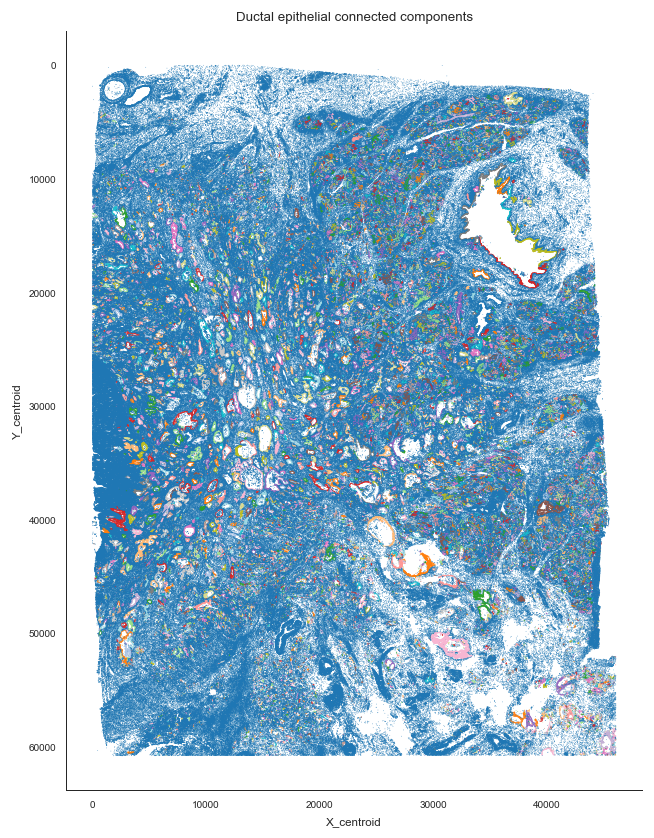

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))
sv.plot_spatial_category(
    adata,
    feature=DUCT_NICHE_KEY,
    point_size=0.18,
    alpha=0.9,
    show_legend=False,
    ax=ax,
)
ax.set_title("Ductal epithelial connected components")
plt.show()

## Build the Cell Graph

The cell graph connects all cells (regardless of phenotype) within **30 µm** (≈ 2–3 cell diameters) using a radius-based adjacency. Edge weights are computed from combined spatial distance and feature similarity.

**Why 30 µm?** This radius captures the immediate microenvironment — the cells physically adjacent to or touching any given cell. It is short enough to be interpretable as direct cell-cell communication range, and long enough to include a full ring of neighbouring cells in densely packed ductal glands.

**What this graph enables:**
- **Niche boundary detection** — cells at the edge of a ductal component have cross-phenotype edges (to fibroblasts, immune cells), while core cells have mostly intra-niche edges
- **Topology summaries** — skeleton length, tortuosity, and branching of the ductal structure can be read from the graph
- **Surroundings** — `surround_hops=5` in subsequent steps walks 5 hops out from the niche boundary, capturing a roughly 150 µm shell of surrounding microenvironment

The `auto_log=True` flag log-transforms skewed morphology and marker features before computing weighted edges, preventing high-variance features from dominating the graph structure.

In [10]:
CELL_GRAPH_FEATURES = present(
    adata.obs.columns,
    [
        "area", "eccentricity", "major_axis_length", "minor_axis_length", "perimeter",
        "convex_area", "equivalent_diameter", "orientation", "solidity", "feret_diameter_max",
        "major_minor_axis_ratio", "perim_square_over_area", "major_axis_equiv_diam_ratio",
        "convex_hull_resid", "centroid_dif", "num_concavities", "circularity",
        "fractal_dimension", "fractual_dimension", "boundary_irregularity", "nc_ratio",
        "polarity_score", "haralick_contrast", "haralick_correlation", "haralick_energy",
        "haralick_homogeneity", "entropy", "pcc_ck19_nak", "intensity_ratio", "inertia",
        "lacunarity", "CK19_expr", "Vimentin_expr", "NaKATPase_expr", "Ki67_expr",
    ],
)
print(f"Cell graph features used: {len(CELL_GRAPH_FEATURES)}")

adata = sv.build_cell_graph(
    adata,
    feature_cols=CELL_GRAPH_FEATURES,
    phenotype_key="Tier_A",
    radius=30 / PIXEL_SIZE_UM,
    image_key="imageid",
    auto_log=True,
    compute_weights=True,
    sigma_space=None,
    sigma_feat=None,
    feature_obsm_key="cell_features",
    adjacency_key="cell_graph_connectivities",
    distance_key="cell_graph_distances",
    graph_obs_key="cell_graph_valid",
)

adata.obsp["cell_graph_connectivities"].shape, adata.obsp["cell_graph_connectivities"].nnz

Cell graph features used: 34


((1763634, 1763634), 43899420)

## Build or Load Niche Feature Table

The niche feature table is the core data structure for trajectory analysis. Each row is one ductal niche (gland), and columns encode:

| Feature group | Prefix | What it captures |
|---|---|---|
| Geometry | `geometry__` | Convex hull shape, circularity, mean cell spacing |
| Graph topology | `topology__` | Skeleton tortuosity, branching points, total length |
| Graph boundary/core | `graph_boundary__` | Fraction of niche cells at the stroma interface; boundary vs core differences in morphology |
| Graph surroundings | `graph_surround__` | Number of cross-phenotype edges from niche to surroundings |
| Cellular state — mean | `state__*__mean` | Average morphology/marker across all cells in the niche |
| Cellular state — spread | `state__*__std`, `__iqr`, `__p10`, `__p90` | **Within-niche heterogeneity** — how variable are cells within the same gland? |

**Why within-niche spread matters:** In organised normal ducts, cells are morphologically homogeneous (low `nc_ratio_std`, low `entropy_std`). In invasive or dysplastic glands, cells become heterogeneous — some cells start to lose polarity, enlarge their nuclei, or disorganise (high spread). The std/IQR features capture this collective disorganisation signal that per-cell means would miss.

**`surround_hops=5` (≈150 µm at 30 µm/hop):** Captures the full peri-ductal stromal and immune zone — the region from which paracrine signals most likely reach the gland.

This computation is expensive (~minutes for a full sample). Results are cached to `notebooks/results/pseudotime_exp2/niche_feature_table.csv`. Set `RECOMPUTE_NICHE_FEATURES = True` only when the underlying data changes.

In [11]:
NICHE_STATE_FEATURES = present(
    adata.obs.columns,
    [
        "area", "eccentricity", "major_axis_length", "minor_axis_length", "perimeter",
        "convex_area", "equivalent_diameter", "orientation", "solidity", "feret_diameter_max",
        "major_minor_axis_ratio", "perim_square_over_area", "major_axis_equiv_diam_ratio",
        "convex_hull_resid", "centroid_dif", "num_concavities", "circularity",
        "fractal_dimension", "fractual_dimension", "boundary_irregularity", "nc_ratio",
        "polarity_score", "haralick_contrast", "haralick_correlation", "haralick_energy",
        "haralick_homogeneity", "entropy", "pcc_ck19_nak", "intensity_ratio", "inertia",
        "lacunarity", "CK19_expr", "Vimentin_expr", "NaKATPase_expr", "Ki67_expr",
    ],
)

if (not RECOMPUTE_NICHE_FEATURES) and NICHE_FEATURE_CACHE.exists():
    niche_feature_df = pd.read_csv(NICHE_FEATURE_CACHE, index_col=0)
elif (not RECOMPUTE_NICHE_FEATURES) and LEGACY_NICHE_FEATURE_CACHE.exists():
    niche_feature_df = pd.read_csv(LEGACY_NICHE_FEATURE_CACHE, index_col=0)
else:
    niche_feature_df = sv.build_niche_feature_table_batched(
        adata,
        niche_key=DUCT_NICHE_KEY,
        batch_size=10,
        include_prefix="global__component",
        exclude_values=("unassigned", "noise"),
        exclude_prefixes=("global__singleton_",),
        feature_cols=NICHE_STATE_FEATURES,
        state_feature_cols=NICHE_STATE_FEATURES,
        phenotype_key="Tier_A",
        min_cells=5,
        include_graph_surroundings=True,
        surround_hops=5,
        include_state_summaries=True,
        state_summary_stats=("mean", "median", "std", "iqr", "p10", "p90"),
        lightweight=False,
        show_progress=True,
        progress_desc="Niche batches",
        show_progress_inner=True,
        progress_desc_inner="Niches in batch",
    )
    niche_feature_df.to_csv(NICHE_FEATURE_CACHE)

print(niche_feature_df.shape)
niche_feature_df.head()

(12184, 544)


,pancreatic ductal epithelium_mask_component,image_id,n_cells,topology__n_nodes,topology__n_edges,topology__density,topology__avg_degree,topology__degree_var,topology__degree_cv,topology__leaf_fraction,...,state__NaKATPase_expr__p90,state__Ki67_expr__mean,state__Ki67_expr__median,state__Ki67_expr__std,state__Ki67_expr__iqr,state__Ki67_expr__p10,state__Ki67_expr__p90,state__phenotype_entropy,state__phenotype_dominant_fraction,state__phenotype__pancreatic_ductal_epithelium__proportion
0,global__component_0,34434_1,8.0,8.0,19.0,0.678571,4.750000,1.937500,0.293040,0.0,...,13.615536,11.804684,11.799242,0.420649,0.538810,11.303032,12.300434,0.0,1.0,1.0
1,global__component_1,34434_1,104.0,104.0,1373.0,0.256348,26.403846,66.452293,0.308736,0.0,...,14.616897,11.208009,11.210027,0.151260,0.165741,11.001950,11.411742,0.0,1.0,1.0
2,global__component_2,34434_1,6.0,6.0,13.0,0.866667,4.333333,0.555556,0.172005,0.0,...,14.044411,11.940049,11.880253,0.317973,0.322176,11.615782,12.324112,0.0,1.0,1.0
3,global__component_3,34434_1,65.0,65.0,730.0,0.350962,22.461538,36.617751,0.269405,0.0,...,14.780220,11.232875,11.215255,0.273521,0.183962,10.993568,11.393604,0.0,1.0,1.0
4,global__component_4,34434_1,10.0,10.0,30.0,0.666667,6.000000,2.600000,0.268742,0.0,...,14.106002,11.409850,11.184746,0.570317,0.455219,10.980649,12.168660,0.0,1.0,1.0


## Add Surrounding Context and Score PDAC Pathology Modules

### Surrounding context
`summarize_niche_surrounding_context` walks 5 graph hops from each niche and computes:
- **Proportion of each cell type** around each niche (immune, stromal, other epithelial)
- **Mean marker expression** of each cell type in the surround (e.g. mean FAP in nearby fibroblasts)

This turns the abstract "graph surroundings" into biologically interpretable features: *how much activated stroma surrounds this gland? How much immune infiltrate?*

### PDAC pathology modules

`score_pdac_niche_pathology_modules` translates the high-dimensional feature table into a small set of interpretable biological axes. Each module is a weighted composite score derived from multiple features:

| Module | Biological meaning | Expected trajectory direction |
|---|---|---|
| `pdac_early_duct_anchor_score` | Well-organised, CK19⁺/NaKATPase⁺ ductal identity; low nc_ratio heterogeneity | **Root of trajectory** (most normal-like) |
| `pdac_panin_like_dysplasia_score` | PanIN-like pre-malignant features: increased nc_ratio, early loss of polarity, mild architectural complexity | Increases early |
| `pdac_invasive_gland_forming_score` | Invasive gland architecture: irregular convex hull, high tortuosity, distorted cell shapes | Increases along invasion arm |
| `pdac_invasion_desmoplasia_axis` | Composite of invasion score + surrounding FAP/aSMA fibroblast enrichment — the tumour-stroma interface axis | Increases toward invasive end |
| `pdac_proliferation_axis` | Ki67 expression + proliferation-associated morphology (cell size, convex hull features) | May peak at an intermediate state |
| `pdac_dedifferentiation_axis` | Loss of CK19/NaKATPase expression, Vimentin gain (mesenchymal shift), increased polarity score variance | Increases in late invasive glands |
| `pdac_duct_organization_score` | Composite of gland geometry regularity and cell homogeneity — how "intact" the ductal architecture is | Decreases along trajectory |
| `pdac_dysplasia_score` | Combined architectural complexity and cellular atypia | Increases |
| `pdac_architectural_complexity_score` | Gland shape irregularity, skeleton branching, boundary fraction | Increases |
| `pdac_invasion_desmoplasia_score` | Pure invasion + stroma score, without proliferation component | Increases |
| `pdac_proliferation_score` | Isolated proliferation signal | Context-dependent |
| `pdac_dedifferentiation_score` | Isolated dedifferentiation signal | Increases late |

**Cell 23** additionally exports which specific features were resolved into each module (via `pathology_module_df.attrs["resolved_module_features"]`), providing full transparency into the module composition for a given dataset.

In [12]:
PHENOTYPE_FEATURE_MAP_CANDIDATES = {
    "Fibroblasts": ["FAP_expr", "aSMA_expr", "PDPN_expr", "Thy1_expr", "Vimentin_expr"],
    DUCT_LABEL: ["CK19_expr", "NaKATPase_expr", "Ki67_expr", "Vimentin_expr"],
    "Endothelial cells": ["CD31_expr", "PDPN_expr"],
    "T cells": ["CD3_expr", "CD4_2_expr", "CD8_2_expr", "FOXP3_2_expr", "GranzymeB_expr", "Ki67_expr"],
    "B lineage": ["CD19_expr", "CD20_expr", "CD27_expr", "CD38_expr", "IgA_expr", "IgM_expr", "PDL1_expr"],
    "Vimentin only mesenchyme": ["Vimentin_expr"],
    "pancreatic acinar epithelium": ["CK19_expr", "NaKATPase_expr", "Vimentin_expr"],
}
phenotype_feature_map = {
    label: present(adata.obs.columns, columns)
    for label, columns in PHENOTYPE_FEATURE_MAP_CANDIDATES.items()
}
phenotype_feature_map = {label: columns for label, columns in phenotype_feature_map.items() if columns}

phenotype_labels = (
    adata.obs["Tier_A"]
    .value_counts()
    .loc[lambda values: ~values.index.isin(["noise", "Unknown"])]
    .index.tolist()
)

surround_context_df = sv.summarize_niche_surrounding_context(
    adata,
    niche_key=DUCT_NICHE_KEY,
    phenotype_key="Tier_A",
    phenotype_labels=phenotype_labels,
    phenotype_feature_map=phenotype_feature_map,
    surround_hops=5,
)

context_cols = [col for col in surround_context_df.columns if col != "n_cells"]
pathology_feature_df = niche_feature_df.merge(
    surround_context_df[context_cols],
    on=[DUCT_NICHE_KEY, "image_id"],
    how="left",
)

pathology_module_df = sv.score_pdac_niche_pathology_modules(
    pathology_feature_df,
    niche_key=DUCT_NICHE_KEY,
    polarity_high_is_organized=True,
)

pathology_feature_df = pathology_feature_df.merge(
    pathology_module_df,
    on=[DUCT_NICHE_KEY, "image_id"],
    how="left",
)

pathology_feature_df.to_csv(RESULT_DIR / "pathology_feature_table_with_modules.csv")
pathology_feature_df.head()

,pancreatic ductal epithelium_mask_component,image_id,n_cells,topology__n_nodes,topology__n_edges,topology__density,topology__avg_degree,topology__degree_var,topology__degree_cv,topology__leaf_fraction,...,pdac_panin_like_dysplasia_score__n_features,pdac_panin_like_dysplasia_score,pdac_invasive_gland_forming_score__n_features,pdac_invasive_gland_forming_score,pdac_invasion_desmoplasia_axis__n_features,pdac_invasion_desmoplasia_axis,pdac_proliferation_axis__n_features,pdac_proliferation_axis,pdac_dedifferentiation_axis__n_features,pdac_dedifferentiation_axis
0,global__component_0,34434_1,8.0,8.0,19.0,0.678571,4.750000,1.937500,0.293040,0.0,...,3.0,-0.826417,4.0,0.815581,1.0,-0.641489,1.0,2.157928,2.0,-0.872942
1,global__component_1,34434_1,104.0,104.0,1373.0,0.256348,26.403846,66.452293,0.308736,0.0,...,3.0,0.088740,4.0,-0.314186,1.0,0.195338,1.0,0.425696,2.0,0.938889
2,global__component_2,34434_1,6.0,6.0,13.0,0.866667,4.333333,0.555556,0.172005,0.0,...,3.0,1.186396,4.0,0.256356,1.0,0.817112,1.0,2.376697,2.0,1.084192
3,global__component_3,34434_1,65.0,65.0,730.0,0.350962,22.461538,36.617751,0.269405,0.0,...,3.0,-0.207391,4.0,0.223649,1.0,0.287697,1.0,0.443866,2.0,-0.081516
4,global__component_4,34434_1,10.0,10.0,30.0,0.666667,6.000000,2.600000,0.268742,0.0,...,3.0,-0.498788,4.0,0.468006,1.0,-0.496942,1.0,1.458422,2.0,-0.455271


In [13]:
resolved_rows = []
for module_name, items in pathology_module_df.attrs.get("resolved_module_features", {}).items():
    for feature, sign in items:
        resolved_rows.append({"module": module_name, "feature": feature, "sign": sign})

resolved_module_features_df = pd.DataFrame(resolved_rows)
resolved_module_features_df.to_csv(RESULT_DIR / "resolved_pdac_module_features.csv", index=False)
resolved_module_features_df

,module,feature,sign
0,pdac_duct_organization_score,geometry__hull_circularity,1.0
1,pdac_duct_organization_score,topology__largest_component_fraction,1.0
2,pdac_duct_organization_score,geometry__mean_nearest_neighbor_distance,1.0
3,pdac_duct_organization_score,state__CK19_expr__mean,1.0
4,pdac_duct_organization_score,state__NaKATPase_expr__mean,1.0
5,pdac_duct_organization_score,state__polarity_score__median,1.0
6,pdac_duct_organization_score,graph_boundary__boundary_fraction,-1.0
7,pdac_duct_organization_score,graph_boundary__mean_external_degree,-1.0
8,pdac_duct_organization_score,topology__bridge_fraction,-1.0
9,pdac_duct_organization_score,topology__skeleton_branchpoint_fraction,-1.0


## Prepare the Pseudotime Feature Matrix

Raw niche features cannot feed directly into trajectory analysis: they are high-dimensional, contain missing values, are highly correlated, and span very different numerical scales.

`prepare_pseudotime_feature_matrix` handles this in a reproducible, package-level step:

1. **Missingness filtering** (`max_na_fraction=0.30`): drops features missing in >30% of niches.
2. **Correlation pruning** (`correlation_threshold=0.75`): within near-identical feature pairs, keeps the one with higher coverage. Threshold tightened from 0.95 → 0.75 to remove within-block redundancy that would otherwise scatter PCA variance across many weakly distinct axes.
3. **Priority features** (`priority_features=MODULE_COLS`): module scores are never pruned in favour of raw features.
4. **Standardisation**: features are mean-centred and scaled before compression.

`block_balance_feature_matrix` reweights so no single category dominates. A subsequent **within-block PCA compression** step then projects each block to its leading 2 principal components, giving the main trajectory PCA a compact, decorrelated representation of each feature family. Without this step, correlated features within the same block (e.g. `solidity__mean` and `solidity__std`) create multiple near-identical PCA axes and dilute the variance explained by PC1.

**Effect**: PC1 should explain substantially more variance after compression, giving ElPiGraph a cleaner axis to fit the principal tree against.


In [14]:
MODULE_COLS = [
    "pdac_early_duct_anchor_score",
    "pdac_panin_like_dysplasia_score",
    "pdac_invasive_gland_forming_score",
    "pdac_invasion_desmoplasia_axis",
    "pdac_proliferation_axis",
    "pdac_dedifferentiation_axis",
    "pdac_duct_organization_score",
    "pdac_dysplasia_score",
    "pdac_architectural_complexity_score",
    "pdac_invasion_desmoplasia_score",
    "pdac_proliferation_score",
    "pdac_dedifferentiation_score",
]

SUPPLEMENTAL_COLS = present(
    pathology_feature_df.columns,
    [
        "geometry__hull_circularity",
        "geometry__mean_nearest_neighbor_distance",
        "graph_boundary__boundary_fraction",
        "graph_boundary__mean_external_degree",
        "graph_surround__cross_edges_per_niche_cell",
        "topology__skeleton_tortuosity",
        "surround_prop__Fibroblasts",
        "surround_prop__Vimentin_only_mesenchyme",
        "surround_prop__Endothelial_cells",
    ],
)

GLAND_PROXY_COLS = present(
    pathology_feature_df.columns,
    [
        "state__solidity__mean", "state__solidity__std",
        "state__perimeter__mean", "state__perimeter__std",
        "state__convex_hull_resid__mean", "state__convex_hull_resid__std",
    ],
)

PIXEL_CONTEXT_COLS = present(
    pathology_feature_df.columns,
    [
        "state__nc_ratio__std", "state__nc_ratio__iqr",
        "state__polarity_score__std", "state__entropy__std", "state__inertia__std",
        "state__lacunarity__std", "state__haralick_contrast__std",
        "state__haralick_correlation__mean", "state__haralick_energy__mean",
        "state__haralick_homogeneity__mean", "state__pcc_ck19_nak__mean",
        "state__pcc_ck19_nak__std", "state__intensity_ratio__mean",
        "state__intensity_ratio__std",
        "graph_boundary__polarity_score__boundary_minus_core",
        "graph_boundary__entropy__boundary_minus_core",
        "graph_boundary__haralick_contrast__boundary_minus_core",
        "graph_boundary__intensity_ratio__boundary_minus_core",
        "graph_boundary__pcc_ck19_nak__boundary_minus_core",
    ],
)

candidate_feature_cols = list(dict.fromkeys(MODULE_COLS + SUPPLEMENTAL_COLS + GLAND_PROXY_COLS + PIXEL_CONTEXT_COLS))
feature_result = prepare_pseudotime_feature_matrix(
    pathology_feature_df,
    feature_cols=candidate_feature_cols,
    priority_features=present(pathology_feature_df.columns, MODULE_COLS),
    max_na_fraction=0.30,
    correlation_threshold=0.75,
    standardize=False,
)

X_path = feature_result.matrix
X_path_balanced, feature_block_df = block_balance_feature_matrix(X_path, return_blocks=True)
feature_result.diagnostics.to_csv(RESULT_DIR / "pseudotime_feature_diagnostics.csv", index=False)
feature_block_df.to_csv(RESULT_DIR / "pseudotime_feature_blocks.csv", index=False)

print(f"Selected {len(feature_result.selected_features)} trajectory features from {len(candidate_feature_cols)} candidates.")
feature_result.diagnostics.head(15)

Selected 35 trajectory features from 46 candidates.


,feature,na_fraction,variance,selected,drop_reason
0,geometry__hull_circularity,0.0,0.020917,True,
1,geometry__mean_nearest_neighbor_distance,0.0,15.159015,True,
2,graph_boundary__boundary_fraction,0.0,0.002581,True,
3,graph_boundary__mean_external_degree,0.0,57.673440,True,
4,pdac_architectural_complexity_score,0.0,0.081288,True,
5,pdac_dedifferentiation_axis,0.0,0.609568,True,
6,pdac_dedifferentiation_score,0.0,0.061893,True,
7,pdac_duct_organization_score,0.0,0.066308,True,
8,pdac_dysplasia_score,0.0,0.344530,True,
9,pdac_early_duct_anchor_score,0.0,0.238618,True,


In [15]:
# Feature block counts
block_counts = feature_block_df["feature_block"].value_counts().rename_axis("feature_block").to_frame("n_features")
display(block_counts)

# Per-feature weights (each feature's column-norm after block balancing, relative to unbalanced)
_raw_col_norms   = np.linalg.norm(X_path,          axis=0)
_bal_col_norms   = np.linalg.norm(X_path_balanced, axis=0)
_weight_ratio    = np.where(_raw_col_norms > 0, _bal_col_norms / _raw_col_norms, 1.0)
block_weight_df  = feature_block_df.copy()
block_weight_df["balance_weight"] = _weight_ratio

print("\nMean balance weight per block (>1 = upweighted, <1 = downweighted):")
display(block_weight_df.groupby("feature_block")["balance_weight"].mean().sort_values(ascending=False).round(3).to_frame())


,n_features
feature_block,
epithelial_state,15
histology_modules,12
architecture_topology,3
microenvironment,3
other,2



Mean balance weight per block (>1 = upweighted, <1 = downweighted):


,balance_weight
feature_block,
epithelial_state,8.575
microenvironment,3.728
histology_modules,0.612
other,0.377
architecture_topology,0.324


In [16]:
# ── Within-block PCA compression ─────────────────────────────────────────────
# Problem: features within the same block remain correlated even after block
# balancing. Their redundant covariance spreads PCA variance across many near-
# identical axes, weakening the leading PCs used by ElPiGraph.
# Solution: compress each block to its top 2 PCs *before* running main PCA.
# Each block then contributes exactly 2 decorrelated axes.
#
# X_path_balanced is a pandas DataFrame; columns are selected by feature name.

from sklearn.decomposition import PCA as _BlockPCA
from sklearn.preprocessing import StandardScaler as _Scaler

_N_PCS_PER_BLOCK = 2   # block-level PCs to retain per feature group

_compressed_parts = []
_compressed_names = []

# feature_block_df has columns: 'feature' (name) and 'feature_block' (group)
for _block_name, _block_group in feature_block_df.groupby("feature_block", sort=False):
    _features  = _block_group["feature"].tolist()              # column names in X_path_balanced
    _block_X   = X_path_balanced[_features].to_numpy()         # numpy array (n_niches × n_block_features)
    _n_keep    = min(_N_PCS_PER_BLOCK, _block_X.shape[1])

    # Standardise within the block before block-PCA
    _block_Xs  = _Scaler().fit_transform(_block_X)
    _pca_b     = _BlockPCA(n_components=_n_keep, random_state=42)
    _block_pcs = _pca_b.fit_transform(_block_Xs)
    _var_expl  = _pca_b.explained_variance_ratio_

    _compressed_parts.append(_block_pcs)
    _compressed_names.extend([
        f"{_block_name}__bPC{i+1}  ({_var_expl[i]*100:.1f}%)" for i in range(_n_keep)
    ])
    print(f"  {_block_name:30s}  {_block_X.shape[1]:2d} features → {_n_keep} block-PCs  "
          f"(cumulative var: {_var_expl[:_n_keep].sum()*100:.1f}%)")

X_path_compressed = np.hstack(_compressed_parts)
print(f"\nCompressed matrix: {X_path_compressed.shape[1]} block-PCs from {X_path_balanced.shape[1]} features")
print("This replaces X_path_balanced as input to the main PCA → ElPiGraph pipeline.")


  histology_modules               12 features → 2 block-PCs  (cumulative var: 58.3%)
  architecture_topology            3 features → 2 block-PCs  (cumulative var: 85.3%)
  other                            2 features → 2 block-PCs  (cumulative var: 100.0%)
  microenvironment                 3 features → 2 block-PCs  (cumulative var: 76.9%)
  epithelial_state                15 features → 2 block-PCs  (cumulative var: 40.2%)

Compressed matrix: 10 block-PCs from 35 features
This replaces X_path_balanced as input to the main PCA → ElPiGraph pipeline.


## PCA, UMAP, and Principal Tree Pseudotime (ElPiGraph)

### Dimensionality reduction

PCA is applied to the **within-block compressed** feature matrix. Because each block is already a compact 2-PC summary of its feature family, the main PCA now operates on a low-redundancy input (~10 axes) and PC1 captures a larger, cleaner fraction of variance. Up to 10 components are computed; the top 5 are used for ElPiGraph.

### ElPiGraph parameters (revised)

- `Lambda=0.02` (smoothness penalty): increased from 0.005 to favour a simpler, more regularised tree. Lower Lambda allowed noisy micro-branches; at 0.02 the tree generalises to the main axes of the data.
- `Mu=0.01` (elasticity): unchanged.
- `NumNodes`: reduced from `n//2` (capped at 60) to `n//600` (capped at 20). For 12,184 niches this gives ~20 nodes — enough to resolve 3–5 biological branches without fitting noise.

**Why these changes matter**: the previous 60-node tree produced 23 branches, many of which were 3-node stubs or near-duplicates sharing 8+ consecutive nodes. A 20-node tree with stronger regularisation should produce 3–6 clean branches that map to distinct biological progression routes.

### Root choice (unchanged)

Root = ElPiGraph node closest to the centroid of the top 10% of niches by `pdac_early_duct_anchor_score`. This anchors pseudotime 0 to the most organised, CK19⁺/NaKATPase⁺ niches — expected spatially in the right (normal pancreas) region of the section.


In [17]:
try:
    from umap import UMAP
    import elpigraph
except Exception as exc:
    raise RuntimeError(
        "Trajectory cells require optional dependencies. "
        "Install with `pip install -e .[trajectory]`."
    ) from exc

n_components = min(10, X_path_compressed.shape[1], max(1, X_path_compressed.shape[0] - 1))
pca = PCA(n_components=n_components)
X_path_pca = pca.fit_transform(X_path_compressed)
n_pcs_path = min(7, X_path_pca.shape[1])
X_path_pca_use = X_path_pca[:, :n_pcs_path]

umap_neighbors = min(10, max(2, X_path_pca_use.shape[0] - 1))
umap_model = UMAP(n_neighbors=umap_neighbors, min_dist=0.2, n_components=2, random_state=42)
X_path_umap = umap_model.fit_transform(X_path_pca_use)

pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance_ratio": np.cumsum(pca.explained_variance_ratio_),
})
pca_summary.to_csv(RESULT_DIR / "pca_explained_variance.csv", index=False)
pca_summary


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,PC,explained_variance_ratio,cumulative_variance_ratio
0,PC1,0.249002,0.249002
1,PC2,0.208454,0.457456
2,PC3,0.194744,0.652200
3,PC4,0.127796,0.779996
4,PC5,0.059453,0.839449
5,PC6,0.048244,0.887693
6,PC7,0.039394,0.927087
7,PC8,0.036810,0.963897
8,PC9,0.022317,0.986214
9,PC10,0.013786,1.000000


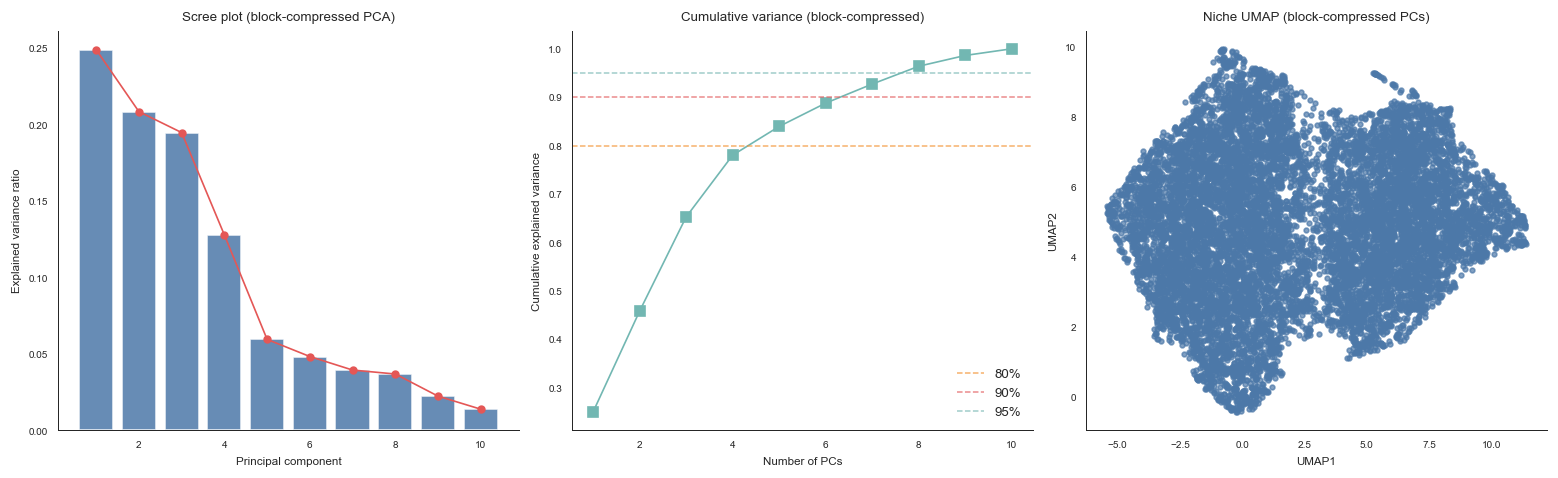


PC1 explains 24.9% of variance.
Top 5 PCs explain 83.9% of variance (used for ElPiGraph).
PCs needed for 80%: 5  |  90%: 7


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Scree
axes[0].bar(np.arange(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_, color="#4c78a8", alpha=0.85)
axes[0].plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
             pca.explained_variance_ratio_, "o-", color="#e45756", ms=4)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance ratio")
axes[0].set_title("Scree plot (block-compressed PCA)")
axes[0].grid(False)

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[1].plot(np.arange(1, len(cumvar)+1), cumvar, "s-", color="#72b7b2")
for thresh, col in [(0.80, "#f28e2b"), (0.90, "#e15759"), (0.95, "#76b7b2")]:
    axes[1].axhline(thresh, ls="--", lw=0.9, color=col, alpha=0.7, label=f"{int(thresh*100)}%")
axes[1].set_xlabel("Number of PCs")
axes[1].set_ylabel("Cumulative explained variance")
axes[1].set_title("Cumulative variance (block-compressed)")
axes[1].legend(frameon=False, fontsize=8)
axes[1].grid(False)

# UMAP
axes[2].scatter(X_path_umap[:, 0], X_path_umap[:, 1], s=8, color="#4c78a8", alpha=0.7)
axes[2].set_xlabel("UMAP1")
axes[2].set_ylabel("UMAP2")
axes[2].set_title("Niche UMAP (block-compressed PCs)")
axes[2].grid(False)

plt.tight_layout()
plt.show()

print(f"\nPC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance.")
print(f"Top 5 PCs explain {cumvar[4]*100:.1f}% of variance (used for ElPiGraph).")
_n80 = int(np.searchsorted(cumvar, 0.80)) + 1
_n90 = int(np.searchsorted(cumvar, 0.90)) + 1
print(f"PCs needed for 80%: {_n80}  |  90%: {_n90}")


In [19]:
num_tree_nodes = min(30, max(8, X_path_pca_use.shape[0] // 400))
pg_tree_path = elpigraph.computeElasticPrincipalTree(
    X=X_path_pca_use,
    NumNodes=num_tree_nodes,
    Lambda=0.02,
    Mu=0.01,
)[0]

root_feature = "pdac_early_duct_anchor_score"
if root_feature not in pathology_feature_df.columns:
    root_feature = "pdac_duct_organization_score"

early_anchor_score = pd.to_numeric(pathology_feature_df.loc[X_path.index, root_feature], errors="coerce")
root_mask = early_anchor_score >= early_anchor_score.quantile(0.9)
if root_mask.fillna(False).sum() == 0:
    root_mask = early_anchor_score == early_anchor_score.max()
root_anchor = X_path_pca_use[root_mask.to_numpy()].mean(axis=0)
source_node_path = int(np.argmin(np.sum((pg_tree_path["NodePositions"] - root_anchor) ** 2, axis=1)))

elpigraph.utils.getPseudotime(
    X=X_path_pca_use,
    PG=pg_tree_path,
    source=source_node_path,
    target=None,
)

proj_path = pg_tree_path["projection"]
meta_cols = [DUCT_NICHE_KEY, "image_id", "n_cells"]
niche_result_pathology = pathology_feature_df.loc[X_path.index, present(pathology_feature_df.columns, meta_cols)].copy()
niche_result_pathology["elpigraph_pseudotime"] = pg_tree_path["pseudotime"]
niche_result_pathology["elpigraph_node_id"] = proj_path["node_id"]
niche_result_pathology["elpigraph_edge_id"] = proj_path["edge_id"]
niche_result_pathology["UMAP1"] = X_path_umap[:, 0]
niche_result_pathology["UMAP2"] = X_path_umap[:, 1]

branch_labels, branch_metadata = infer_branch_labels(
    pg_tree_path,
    niche_result_pathology,
    source_node=source_node_path,
    node_col="elpigraph_node_id",
)
niche_result_pathology["principal_tree_branch"] = branch_labels.to_numpy()

niche_result_pathology.to_csv(RESULT_DIR / "niche_pseudotime_results.csv", index=False)
branch_metadata

{'hub_node': 2,
 'source_node': 23,
 'trunk_path': [23, 2],
 'branch_paths': {'branch 1': [2, 0, 21, 8],
  'branch 2': [2, 0, 9, 4, 12, 1, 24, 11],
  'branch 3': [2, 0, 9, 4, 12, 1, 10, 29, 3, 15],
  'branch 4': [2, 0, 5, 20, 16],
  'branch 5': [2, 0, 9, 4, 17],
  'branch 6': [2, 0, 19],
  'branch 7': [2, 0, 6, 27, 25],
  'branch 8': [2, 0, 9, 4, 12, 1, 22, 7, 26],
  'branch 9': [2, 18, 28, 13]}}

In [20]:
# ── Quantile-normalised pseudotime ───────────────────────────────────────────
# Raw ElPiGraph pseudotime = geodesic distance along the tree.  When many
# niches project onto the same short tree edge they get nearly identical
# distance values and visually pile up.  Quantile normalisation redistributes
# them to a uniform [0, 1] scale *without changing their rank order*, stretching
# compressed regions and making module trends much easier to read.
#
# Two versions are added:
#   elpigraph_pseudotime_q  – global rank over all niches (0 → 1)
#   elpigraph_pseudotime_qb – per-branch rank (0 → 1 within each branch)
#     useful for branch-stratified scatter where you want even spread per arm.

from scipy.stats import rankdata as _rankdata

_pt_col = "elpigraph_pseudotime"

# Global quantile
_valid = niche_result_pathology[_pt_col].notna()
_n = _valid.sum()
_ranks = _rankdata(niche_result_pathology.loc[_valid, _pt_col], method="average")
niche_result_pathology.loc[_valid, "elpigraph_pseudotime_q"] = (_ranks - 1) / (_n - 1)

# Per-branch quantile
niche_result_pathology["elpigraph_pseudotime_qb"] = np.nan
for _branch, _grp in niche_result_pathology.groupby("principal_tree_branch", dropna=True):
    _v = _grp[_pt_col].notna()
    if _v.sum() < 2:
        continue
    _r = _rankdata(_grp.loc[_v, _pt_col], method="average")
    niche_result_pathology.loc[_grp.index[_v], "elpigraph_pseudotime_qb"] = (_r - 1) / (_r.max() - 1)

niche_result_pathology.to_csv(RESULT_DIR / "niche_pseudotime_results.csv", index=False)

print("Pseudotime distribution (global quantile):")
print(niche_result_pathology["elpigraph_pseudotime_q"].describe().round(3))


Pseudotime distribution (global quantile):
count    12184.000
mean         0.500
std          0.289
min          0.005
25%          0.252
50%          0.500
75%          0.750
max          0.994
Name: elpigraph_pseudotime_q, dtype: float64


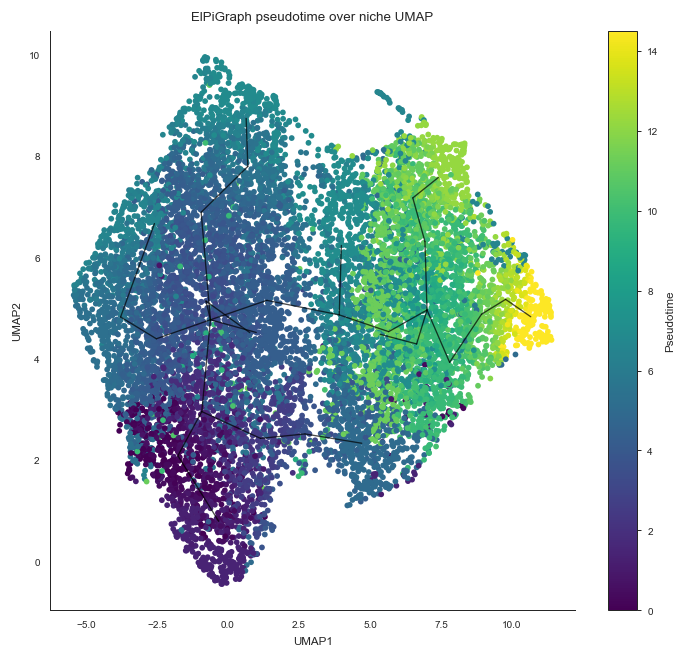

In [21]:
tree_node_embedding_df = project_tree_nodes_to_embedding(
    niche_result_pathology,
    node_col="elpigraph_node_id",
    embedding_cols=["UMAP1", "UMAP2"],
).set_index("node_id")

fig, ax = plt.subplots(figsize=(6, 5.5))
sc = ax.scatter(
    niche_result_pathology["UMAP1"],
    niche_result_pathology["UMAP2"],
    c=niche_result_pathology["elpigraph_pseudotime"],
    cmap="viridis",
    s=12,
    linewidths=0,
)
for node_a, node_b in tree_edges(pg_tree_path):
    if node_a in tree_node_embedding_df.index and node_b in tree_node_embedding_df.index:
        xy = tree_node_embedding_df.loc[[node_a, node_b], ["UMAP1", "UMAP2"]].to_numpy()
        ax.plot(xy[:, 0], xy[:, 1], color="black", linewidth=0.8, alpha=0.7)
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.set_title("ElPiGraph pseudotime over niche UMAP")
ax.grid(False)
plt.colorbar(sc, ax=ax, label="Pseudotime")
plt.tight_layout()
plt.show()

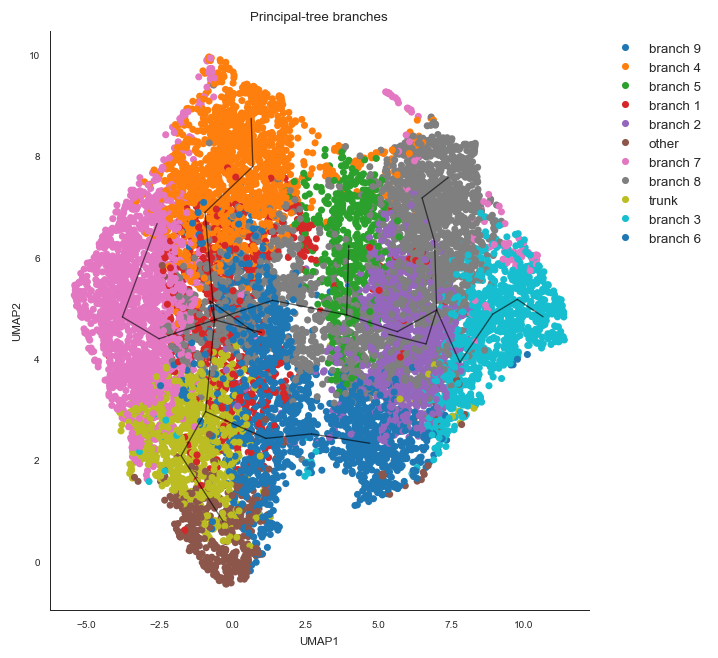

In [22]:
fig, ax = plt.subplots(figsize=(6, 5.5))
sns.scatterplot(
    data=niche_result_pathology,
    x="UMAP1",
    y="UMAP2",
    hue="principal_tree_branch",
    s=18,
    linewidth=0,
    palette="tab10",
    ax=ax,
)
for node_a, node_b in tree_edges(pg_tree_path):
    if node_a in tree_node_embedding_df.index and node_b in tree_node_embedding_df.index:
        xy = tree_node_embedding_df.loc[[node_a, node_b], ["UMAP1", "UMAP2"]].to_numpy()
        ax.plot(xy[:, 0], xy[:, 1], color="black", linewidth=0.8, alpha=0.6)
ax.set_title("Principal-tree branches")
ax.grid(False)
ax.legend(frameon=False, fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Map Niche Pseudotime Back to Cells

Each ductal cell inherits the pseudotime, branch label, and tree-node assignment of its parent niche. Non-ductal cells (fibroblasts, immune cells) receive NaN — they are not part of the trajectory, but will appear as background in the spatial visualisation.

The spatial pseudotime plot immediately below is one of the most interpretable outputs of this analysis: **it shows where the trajectory falls in tissue space**. In a PDAC section with an anatomical gradient (normal pancreas → invasive front), we expect:
- **Low pseudotime (early, blue)** — right side, well-organised ducts in the residual normal pancreas region
- **High pseudotime (late, yellow)** — left/centre, invasive glands in the desmoplastic stroma abutting the duodenum

If the pseudotime map shows a coherent spatial gradient, it validates that the trajectory captured a biologically meaningful axis of organisation. A spatially scrambled pseudotime would indicate that the feature matrix is dominated by technical or cell-size effects rather than genuine tissue architecture.

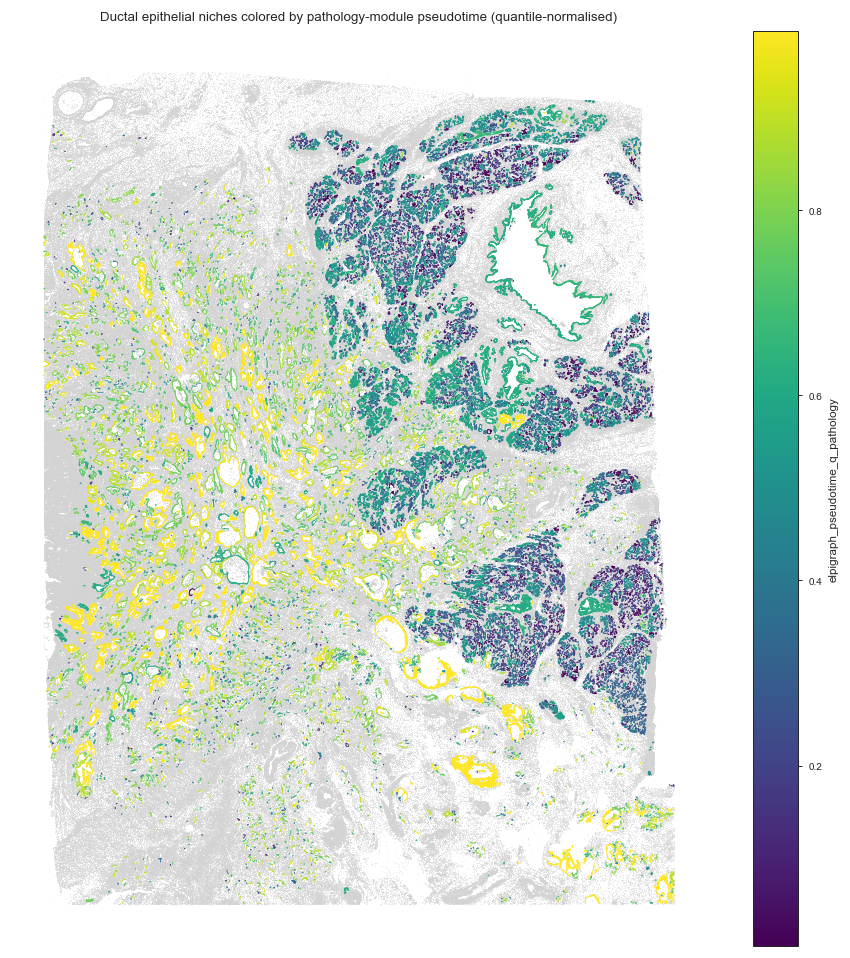

(<Figure size 960x960 with 2 Axes>,
 <Axes: title={'center': 'Ductal epithelial niches colored by pathology-module pseudotime (quantile-normalised)'}>)

In [23]:
niche_lookup = niche_result_pathology.set_index([DUCT_NICHE_KEY, "image_id"])[
    ["elpigraph_pseudotime", "elpigraph_pseudotime_q", "elpigraph_pseudotime_qb",
     "elpigraph_node_id", "elpigraph_edge_id", "principal_tree_branch"]
]
cell_lookup_index = pd.MultiIndex.from_frame(
    adata.obs[[DUCT_NICHE_KEY, "imageid"]].rename(columns={"imageid": "image_id"})
)
cell_lookup = niche_lookup.reindex(cell_lookup_index)

adata.obs["elpigraph_pseudotime_pathology"] = cell_lookup["elpigraph_pseudotime"].to_numpy()
adata.obs["elpigraph_pseudotime_q_pathology"] = cell_lookup["elpigraph_pseudotime_q"].to_numpy()
adata.obs["elpigraph_pseudotime_qb_pathology"] = cell_lookup["elpigraph_pseudotime_qb"].to_numpy()
adata.obs["elpigraph_node_id_pathology"] = cell_lookup["elpigraph_node_id"].to_numpy()
adata.obs["elpigraph_edge_id_pathology"] = cell_lookup["elpigraph_edge_id"].to_numpy()
adata.obs["principal_tree_branch_pathology"] = cell_lookup["principal_tree_branch"].to_numpy()

plot_continuous_spatial(
    adata.obs,
    "elpigraph_pseudotime_q_pathology",
    title="Ductal epithelial niches colored by pathology-module pseudotime (quantile-normalised)",
    background_mask=adata.obs["elpigraph_pseudotime_q_pathology"].isna(),
    point_size=0.22,
)

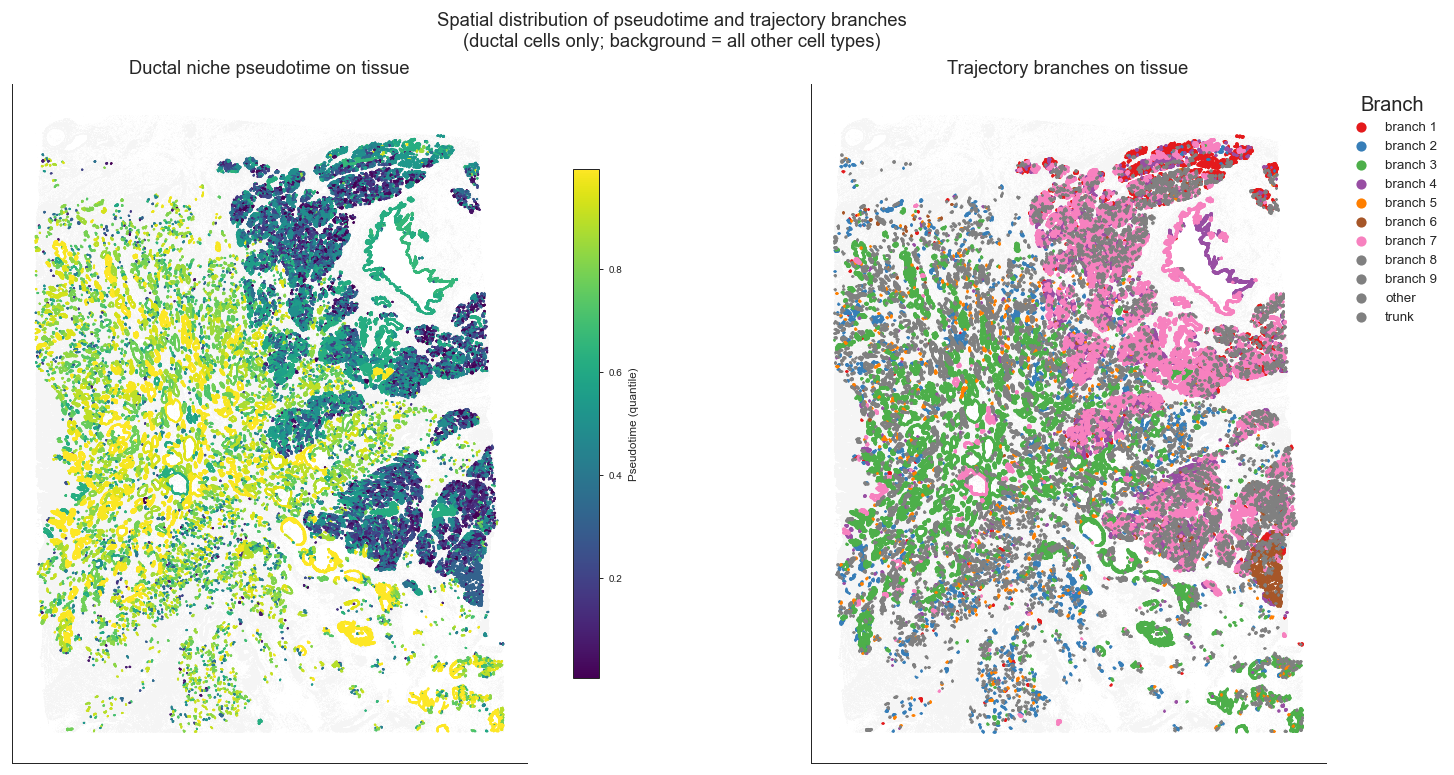

In [24]:
# Spatial map of trajectory branches — each gland coloured by its principal-tree branch
# This reveals whether different routes of progression are spatially segregated in tissue
branch_colors = {
    b: c for b, c in zip(
        sorted(adata.obs['principal_tree_branch_pathology'].dropna().unique()),
        ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', '#a65628', '#f781bf'],
    )
}
branch_colors['unassigned'] = 'lightgray'

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, (col, title) in zip(
    axes,
    [
        ('elpigraph_pseudotime_q_pathology', 'Pseudotime (quantile-normalised)'),
        ('principal_tree_branch_pathology', 'Trajectory branch'),
    ],
):
    # Background: all non-ductal cells
    non_duct = adata.obs[adata.obs[col].isna()]
    ax.scatter(
        non_duct['X_centroid'], non_duct['Y_centroid'],
        c='whitesmoke', s=0.2, alpha=0.2, linewidths=0, rasterized=True,
    )

if 'elpigraph_pseudotime_q_pathology' in adata.obs.columns:
    duct_obs = adata.obs[adata.obs['elpigraph_pseudotime_q_pathology'].notna()].copy()

    # Panel 1: continuous pseudotime
    sc = axes[0].scatter(
        duct_obs['X_centroid'], duct_obs['Y_centroid'],
        c=duct_obs['elpigraph_pseudotime_q_pathology'],
        cmap='viridis', s=1.2, linewidths=0, rasterized=True,
    )
    plt.colorbar(sc, ax=axes[0], label='Pseudotime (quantile)', shrink=0.75)
    axes[0].set_title('Ductal niche pseudotime on tissue', fontsize=11)

    # Panel 2: discrete branches
    branches = sorted(duct_obs['principal_tree_branch_pathology'].dropna().unique())
    for branch in branches:
        sub = duct_obs[duct_obs['principal_tree_branch_pathology'] == branch]
        axes[1].scatter(
            sub['X_centroid'], sub['Y_centroid'],
            c=branch_colors.get(str(branch), 'gray'),
            s=1.5, linewidths=0, label=str(branch), rasterized=True,
        )
    axes[1].legend(
        title='Branch', fontsize=8, markerscale=5,
        bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
    )
    axes[1].set_title('Trajectory branches on tissue', fontsize=11)

for ax in axes:
    ax.invert_yaxis(); ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(
    'Spatial distribution of pseudotime and trajectory branches\n'
    '(ductal cells only; background = all other cell types)',
    fontsize=11,
)
fig.tight_layout()


Spearman(pseudotime, X_centroid) = -0.489  p = 0.00e+00
Spearman(pseudotime, Y_centroid) = +0.228  p = 1.95e-143

✓  Pseudotime decreases from left → right (high X = normal pancreas = low pseudotime). Direction is correct.


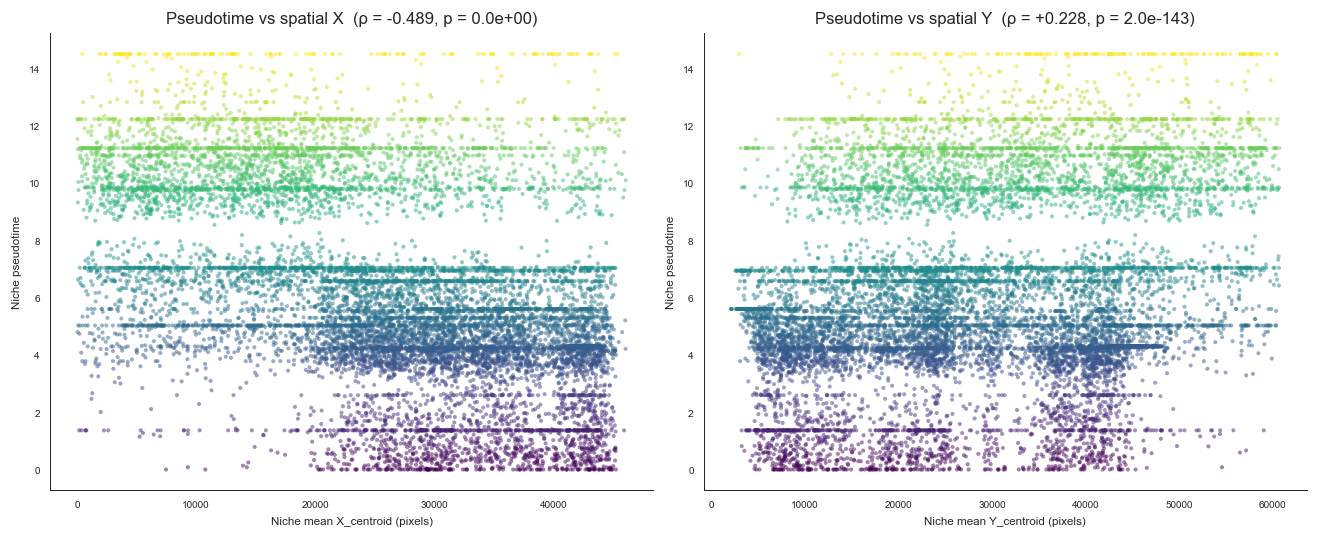

In [25]:
# ── Spatial validation of pseudotime direction ───────────────────────────────
# Biological expectation: low pseudotime = organised ducts = RIGHT side of
# section (normal pancreas); high pseudotime = invasive glands = LEFT / centre.
# If pseudotime anti-correlates with spatial X_centroid (rho < 0), the
# trajectory is biologically directed as intended.
# A weak or positive correlation would indicate the root anchoring failed or
# that the tissue orientation is atypical for this image.

from scipy.stats import spearmanr as _spearmanr

# Map per-cell pseudotime → per-niche mean X / Y centroid
_cell_pt = adata.obs[["elpigraph_pseudotime_pathology", "X_centroid", "Y_centroid", DUCT_NICHE_KEY, "imageid"]].copy()
_cell_pt = _cell_pt[_cell_pt["elpigraph_pseudotime_pathology"].notna()].copy()
_niche_spatial = (
    _cell_pt.groupby([DUCT_NICHE_KEY, "imageid"], observed=True)
    .agg(
        pseudotime=("elpigraph_pseudotime_pathology", "median"),
        x_centroid=("X_centroid", "mean"),
        y_centroid=("Y_centroid", "mean"),
        n_cells=("elpigraph_pseudotime_pathology", "count"),
    )
    .reset_index()
)

_rho_x, _p_x = _spearmanr(_niche_spatial["x_centroid"], _niche_spatial["pseudotime"])
_rho_y, _p_y = _spearmanr(_niche_spatial["y_centroid"], _niche_spatial["pseudotime"])

print(f"Spearman(pseudotime, X_centroid) = {_rho_x:+.3f}  p = {_p_x:.2e}")
print(f"Spearman(pseudotime, Y_centroid) = {_rho_y:+.3f}  p = {_p_y:.2e}")
print()
if _rho_x < -0.10 and _p_x < 0.05:
    print("✓  Pseudotime decreases from left → right (high X = normal pancreas = low pseudotime). Direction is correct.")
elif _rho_x > 0.10 and _p_x < 0.05:
    print("⚠  Pseudotime increases left → right. Check tissue orientation or root anchoring.")
else:
    print("~  Weak X correlation — trajectory may capture state heterogeneity not purely explained by spatial position.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc0 = axes[0].scatter(
    _niche_spatial["x_centroid"], _niche_spatial["pseudotime"],
    c=_niche_spatial["pseudotime"], cmap="viridis",
    s=6, alpha=0.5, linewidths=0, rasterized=True,
)
axes[0].set_xlabel("Niche mean X_centroid (pixels)")
axes[0].set_ylabel("Niche pseudotime")
axes[0].set_title(f"Pseudotime vs spatial X  (ρ = {_rho_x:+.3f}, p = {_p_x:.1e})", fontsize=10)
axes[0].grid(False)

sc1 = axes[1].scatter(
    _niche_spatial["y_centroid"], _niche_spatial["pseudotime"],
    c=_niche_spatial["pseudotime"], cmap="viridis",
    s=6, alpha=0.5, linewidths=0, rasterized=True,
)
axes[1].set_xlabel("Niche mean Y_centroid (pixels)")
axes[1].set_ylabel("Niche pseudotime")
axes[1].set_title(f"Pseudotime vs spatial Y  (ρ = {_rho_y:+.3f}, p = {_p_y:.1e})", fontsize=10)
axes[1].grid(False)

plt.tight_layout()
plt.show()


## Module Trends Along Pseudotime

`compute_feature_trend_table` quantifies how each pathology module score changes along the trajectory: it returns the Spearman correlation (rho), early-vs-late median shift, and FDR-corrected p-values for each feature. The LOWESS curves in the plot below smooth the per-niche scatter to reveal the underlying trend.

**Expected patterns in PDAC sample 34434_1:**

| Module | Expected trend | Biological interpretation |
|---|---|---|
| `early_duct_anchor_score` | Decreases monotonically | Organised ductal architecture is progressively lost |
| `panin_like_dysplasia_score` | Rises then plateaus | PanIN-like features peak at pre-invasive stage |
| `invasive_gland_forming_score` | Rises steeply in late pseudotime | Gland architecture becomes irregular as tumour invades |
| `invasion_desmoplasia_axis` | Rises, especially in invasion-branch niches | Co-evolution of invasion and activated stroma |
| `proliferation_axis` | Peak at intermediate pseudotime | Proliferation peaks during active invasion, declines in terminal dedifferentiated state |
| `dedifferentiation_axis` | Rises in late pseudotime | Loss of differentiation markers (CK19, NaKATPase) in most invasive glands |

**Branch-specific patterns** (coloured lines): different branches may show divergent trajectories — e.g. one branch that is proliferation-high and invasion-low (proliferative arm) vs one that is invasion-high and proliferation-low (dedifferentiated invasive arm). This branching carries mechanistic implications for PDAC subtype biology.

In [26]:
plot_df = pathology_feature_df.merge(
    niche_result_pathology[[DUCT_NICHE_KEY, "image_id", "elpigraph_pseudotime", "elpigraph_pseudotime_q", "elpigraph_edge_id", "principal_tree_branch"]],
    on=[DUCT_NICHE_KEY, "image_id"],
    how="left",
)

module_plot_cols = present(plot_df.columns, MODULE_COLS[:6])
module_specs = [
    {
        "feature": col,
        "label": col.replace("pdac_", "").replace("_", " "),
        "category": "PDAC pathology module",
    }
    for col in module_plot_cols
]
module_trend_table = compute_feature_trend_table(
    plot_df,
    module_specs,
    pseudotime_col="elpigraph_pseudotime",
    group_name="PDAC_34434_1",
    min_n=15,
)
module_trend_table.to_csv(RESULT_DIR / "pdac_module_pseudotime_trends.csv", index=False)
module_trend_table

,group,category,feature,label,n,spearman_r,spearman_p,early_quantile,late_quantile,early_median,late_median,late_minus_early_median,mannwhitney_p_early_vs_late,spearman_fdr,mannwhitney_fdr
0,PDAC_34434_1,PDAC pathology module,pdac_panin_like_dysplasia_score,panin like dysplasia score,12184,0.367136,0.000000e+00,0.1,0.9,-0.674732,0.217713,0.892445,1.238651e-244,0.000000e+00,7.431906e-244
1,PDAC_34434_1,PDAC pathology module,pdac_dedifferentiation_axis,dedifferentiation axis,12184,0.189461,7.599793e-99,0.1,0.9,-0.884790,-0.073916,0.810874,3.706931e-161,1.519959e-98,7.413862e-161
2,PDAC_34434_1,PDAC pathology module,pdac_proliferation_axis,proliferation axis,12184,0.104384,7.181415e-31,0.1,0.9,-0.238194,0.292050,0.530244,5.145876e-35,8.617697e-31,6.175051e-35
3,PDAC_34434_1,PDAC pathology module,pdac_invasion_desmoplasia_axis,invasion desmoplasia axis,12184,-0.057086,2.868602e-10,0.1,0.9,-0.046537,-0.254474,-0.207937,7.623890e-15,2.868602e-10,7.623890e-15
4,PDAC_34434_1,PDAC pathology module,pdac_invasive_gland_forming_score,invasive gland forming score,12184,-0.119609,4.586188e-40,0.1,0.9,0.378762,0.018715,-0.360048,3.538197e-85,6.879282e-40,5.307295e-85
5,PDAC_34434_1,PDAC pathology module,pdac_early_duct_anchor_score,early duct anchor score,12184,-0.432381,0.000000e+00,0.1,0.9,0.558692,-0.294996,-0.853688,6.961908e-204,0.000000e+00,2.088573e-203


/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/shihongwu/anaconda3/envs/spatioev_env/lib/python3.11/site-packages/statsmodels/nonparametric/smoothers_lo

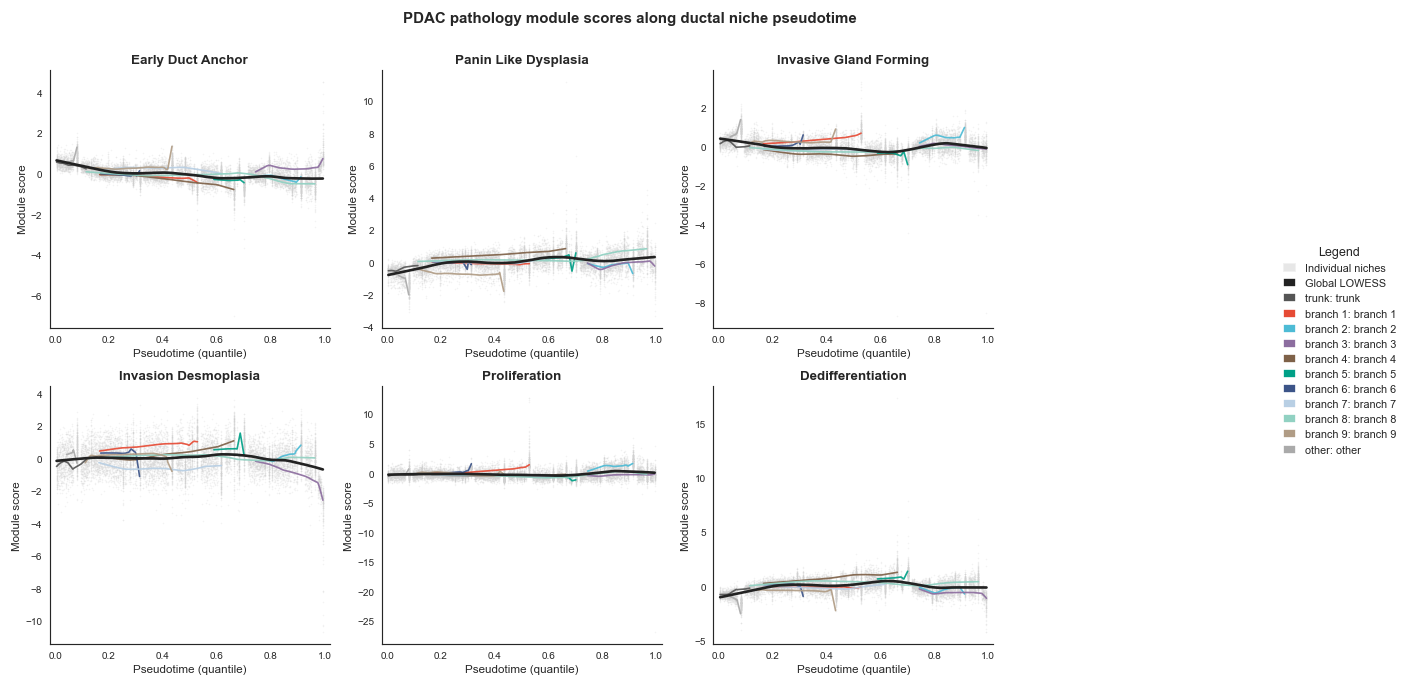


Figure saved: module_trends_publication.pdf / .png


In [27]:
import statsmodels.api as sm
import matplotlib as mpl
import matplotlib.patches as mpatches

# ── Consistent branch colour palette (works in print + colour) ────────────────
_BRANCH_PAL = {
    "trunk":     "#555555",
    "branch 1":  "#E64B35",   # proliferative — red
    "branch 2":  "#4DBBD5",   # organised ducts — cyan
    "branch 3":  "#8C6D9F",   # dedifferentiated — purple
    "branch 4":  "#7E6148",   # dedifferentiated — brown
    "branch 5":  "#00A087",   # desmoplastic invasion — teal
    "branch 6":  "#3C5488",   # PanIN-like — navy
    "branch 7":  "#B8CFE4",   # PanIN-like — pale blue
    "branch 8":  "#91D1C2",   # organised ducts — mint
    "branch 9":  "#B09C85",   # organised ducts — sand
    "branch 10": "#F39B7F",   # invasive — salmon
}

# ── Figure parameters (Nature-style) ─────────────────────────────────────────
mpl.rcParams.update({
    "font.family":         "sans-serif",
    "font.size":           7,
    "axes.titlesize":      8,
    "axes.labelsize":      7,
    "xtick.labelsize":     6,
    "ytick.labelsize":     6,
    "xtick.major.size":    2.5,
    "ytick.major.size":    2.5,
    "xtick.major.width":   0.7,
    "ytick.major.width":   0.7,
    "axes.linewidth":      0.7,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "lines.linewidth":     1.2,
    "figure.facecolor":    "white",
    "savefig.facecolor":   "white",
})

# Use quantile-normalised pseudotime on x-axis for even spread
_PT_DISPLAY = "elpigraph_pseudotime_q"   # 0 → 1, uniformly distributed

n_mods = len(module_plot_cols)
n_cols = 3
n_rows = (n_mods + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(3.5 * n_cols, 2.8 * n_rows),
                         squeeze=False)
axes_flat = axes.ravel()

# Track which branches were already added to the legend
_legend_patches = {}

for ax, col in zip(axes_flat, module_plot_cols):
    tmp = plot_df[[_PT_DISPLAY, "elpigraph_pseudotime", "principal_tree_branch", col]].dropna(
        subset=[_PT_DISPLAY, col]
    ).sort_values(_PT_DISPLAY)

    # Background scatter — tiny, rasterized for PDF size
    ax.scatter(
        tmp[_PT_DISPLAY], tmp[col],
        s=0.8, c="#d0d0d0", alpha=0.25,
        linewidths=0, rasterized=True, zorder=1,
    )

    # Global LOWESS (dark charcoal)
    if len(tmp) >= 20:
        _lw = sm.nonparametric.lowess(tmp[col], tmp[_PT_DISPLAY], frac=0.3, return_sorted=True)
        ax.plot(_lw[:, 0], _lw[:, 1], color="#222222", linewidth=1.6, zorder=4, solid_capstyle="round")

    # Per-branch LOWESS (coloured)
    for _branch, _bdf in tmp.groupby("principal_tree_branch", dropna=True):
        if len(_bdf) < 15:
            continue
        _col = _BRANCH_PAL.get(str(_branch), "#aaaaaa")
        _lw_b = sm.nonparametric.lowess(
            _bdf[col], _bdf[_PT_DISPLAY], frac=0.35, return_sorted=True
        )
        ax.plot(_lw_b[:, 0], _lw_b[:, 1],
                color=_col, linewidth=1.0, alpha=0.92, zorder=3, solid_capstyle="round")
        # Build legend entry (first encounter only)
        if str(_branch) not in _legend_patches:
            _bio = globals().get('branch_bio_names', {}).get(_branch, str(_branch))
            # Shorten label: strip "branch N — " prefix, keep the biological part
            _short = _bio.split(" — ", 1)[-1] if " — " in _bio else _bio
            _legend_patches[str(_branch)] = mpatches.Patch(facecolor=_col, label=f"{_branch}: {_short}")

    # Axis cosmetics
    _title = (col.replace("pdac_","").replace("_score","").replace("_axis","")
                 .replace("_"," ").strip().title())
    ax.set_title(_title, pad=4, fontweight="semibold")
    ax.set_xlabel("Pseudotime (quantile)", labelpad=2)
    ax.set_ylabel("Module score", labelpad=2)
    ax.set_xlim(-0.02, 1.02)
    ax.tick_params(axis="both", length=2.5, pad=2)

# Turn off unused subplot panels
for ax in axes_flat[n_mods:]:
    ax.set_visible(False)

# ── Shared legend outside the grid (right side) ──────────────────────────────
# Sort legend by branch number: trunk first, then branches in order
def _sort_key(item):
    k = item[0]
    if k == "trunk": return -1
    try: return int(k.split()[-1])
    except: return 999

_sorted_patches = [v for _, v in sorted(_legend_patches.items(), key=_sort_key)]
_sorted_patches.insert(0, mpatches.Patch(facecolor="#222222", label="Global LOWESS"))
_sorted_patches.insert(0, mpatches.Patch(facecolor="#d0d0d0", label="Individual niches", alpha=0.5))

fig.legend(
    handles=_sorted_patches,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    frameon=False,
    fontsize=6.5,
    title="Legend",
    title_fontsize=7.5,
    handlelength=1.2,
    handleheight=0.9,
    borderpad=0.5,
    labelspacing=0.45,
)

fig.suptitle(
    "PDAC pathology module scores along ductal niche pseudotime",
    fontsize=9, fontweight="bold", y=1.005,
)

plt.tight_layout(rect=[0, 0, 0.80, 1])
plt.savefig(RESULT_DIR / "module_trends_publication.pdf", dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.savefig(RESULT_DIR / "module_trends_publication.png", dpi=300, bbox_inches="tight",
            facecolor="white", edgecolor="none")
plt.show()
print(f"\nFigure saved: module_trends_publication.pdf / .png")


## Branch and Branch-Time Summaries

The principal tree may resolve into 2–4 branches from the root. Each branch represents a distinct route of niche progression.

**How to interpret the branches:**
- **The trunk** (branch 0, near root): shared early trajectory — organised ducts losing normal architecture, mild dysplasia beginning
- **Proliferative branch**: high `pdac_proliferation_axis`, moderate `invasion_desmoplasia_axis` — actively growing glands still retaining some ductal organisation
- **Invasive-desmoplastic branch**: high `invasion_desmoplasia_axis` and `invasive_gland_forming_score`, lower proliferation — glands deeply embedded in activated stroma, with irregular architecture and high CAF context
- **Dedifferentiated branch** (if present): high `dedifferentiation_axis`, low `early_duct_anchor_score` — glands losing ductal identity entirely

`add_branch_time_bins` divides each branch into early/middle/late thirds, and `find_branch_transition_features` identifies which module scores show the largest shift between adjacent time bins. Features with `min_abs_delta=0.5` are genuine transition markers (half a standard deviation change).

In [28]:
# ── Non-linear module trend characterisation ─────────────────────────────────
# Spearman correlation captures monotonic trends but misses U-shaped or peaked
# relationships (e.g. invasion_desmoplasia_axis peaks at mid-pseudotime).
# Here we fit a quadratic regression and LOWESS to each module, and report:
#   - quadratic R²  (how much variance is explained by a non-linear fit)
#   - peak pseudotime (quantile at which the LOWESS-smoothed score is maximum)
#   - trend shape: monotone-up / monotone-down / peaked / valley / flat
import statsmodels.api as sm
from scipy.stats import pearsonr

_pt_key = "elpigraph_pseudotime"
_mod_cols = module_plot_cols

_trend_rows = []
for _col in _mod_cols:
    _tmp = plot_df[[_pt_key, _col]].dropna().sort_values(_pt_key)
    if len(_tmp) < 30:
        continue
    _pt_vals = _tmp[_pt_key].to_numpy()
    _y_vals  = _tmp[_col].to_numpy()

    # Quadratic fit
    _X_poly = np.column_stack([_pt_vals, _pt_vals**2])
    _X_poly = sm.add_constant(_X_poly)
    try:
        _res = sm.OLS(_y_vals, _X_poly).fit()
        _r2_quad = _res.rsquared
    except Exception:
        _r2_quad = float("nan")

    # LOWESS peak
    _lowess = sm.nonparametric.lowess(_y_vals, _pt_vals, frac=0.3, return_sorted=True)
    _peak_pt  = _lowess[np.argmax(_lowess[:, 1]), 0]
    _trough_pt = _lowess[np.argmin(_lowess[:, 1]), 0]
    _pt_range  = _pt_vals.max() - _pt_vals.min()

    # Shape classification
    _pt_mid   = _pt_vals.min() + 0.5 * _pt_range
    _mid_frac = (_peak_pt - _pt_vals.min()) / (_pt_range + 1e-9)
    _spearman_r = plot_df[[_pt_key, _col]].dropna().corr(method="spearman").iloc[0, 1]
    if abs(_spearman_r) >= 0.15:
        _shape = "monotone-up" if _spearman_r > 0 else "monotone-down"
    elif 0.25 <= _mid_frac <= 0.75:
        _shape = "peaked" if _lowess[-1, 1] < _lowess[int(len(_lowess)*0.5), 1] else "valley"
    else:
        _shape = "edge-peaked"

    _trend_rows.append({
        "module": _col.replace("pdac_","").replace("_score","").replace("_axis","").replace("_"," "),
        "spearman_r": round(_spearman_r, 3),
        "quadratic_R2": round(_r2_quad, 3),
        "peak_pseudotime": round(_peak_pt, 3),
        "peak_pt_quantile": round(
            (_peak_pt - _pt_vals.min()) / (_pt_range + 1e-9), 2
        ),
        "trend_shape": _shape,
    })

trend_shape_df = pd.DataFrame(_trend_rows).sort_values("quadratic_R2", ascending=False)
trend_shape_df.to_csv(RESULT_DIR / "module_nonlinear_trend_shapes.csv", index=False)
print("Module trend shapes (quadratic R² > Spearman² → genuinely non-linear):")
display(trend_shape_df)


Module trend shapes (quadratic R² > Spearman² → genuinely non-linear):


,module,spearman_r,quadratic_R2,peak_pseudotime,peak_pt_quantile,trend_shape
0,early duct anchor,-0.432,0.260,0.000,0.00,monotone-down
5,dedifferentiation,0.189,0.235,7.040,0.49,monotone-up
1,panin like dysplasia,0.367,0.189,6.999,0.48,monotone-up
3,invasion desmoplasia,-0.057,0.097,7.165,0.49,peaked
2,invasive gland forming,-0.120,0.080,0.000,0.00,edge-peaked
4,proliferation,0.104,0.031,10.577,0.73,valley


In [29]:
branch_summary_df = summarize_branches(
    plot_df,
    branch_col="principal_tree_branch",
    pseudotime_col="elpigraph_pseudotime",
    score_cols=module_plot_cols,
)
branch_summary_df.to_csv(RESULT_DIR / "branch_summary.csv", index=False)
branch_summary_df

,branch,n_observations,fraction_of_all_observations,median_pseudotime,min_pseudotime,max_pseudotime,pdac_early_duct_anchor_score__median,pdac_early_duct_anchor_score__z_enrichment,pdac_panin_like_dysplasia_score__median,pdac_panin_like_dysplasia_score__z_enrichment,pdac_invasive_gland_forming_score__median,pdac_invasive_gland_forming_score__z_enrichment,pdac_invasion_desmoplasia_axis__median,pdac_invasion_desmoplasia_axis__z_enrichment,pdac_proliferation_axis__median,pdac_proliferation_axis__z_enrichment,pdac_dedifferentiation_axis__median,pdac_dedifferentiation_axis__z_enrichment
0,branch 1,886,0.072718,4.801507,3.524239,5.604204,-0.169853,-0.370414,-0.055022,-0.117910,0.389597,0.872367,0.815186,0.811630,0.558217,0.751027,-0.067259,-0.075913
1,branch 2,942,0.077315,10.708692,9.142729,11.222182,-0.305497,-0.648096,-0.141783,-0.250143,0.471706,1.045797,0.190196,0.186640,1.342865,1.535674,-0.183952,-0.225376
2,branch 3,1010,0.082896,10.911301,9.112674,14.505467,0.347104,0.687873,-0.165340,-0.286046,0.014758,0.080641,-0.953017,-0.956574,-0.324681,-0.131872,-0.643277,-0.813690
3,branch 4,1556,0.127708,5.366238,3.539015,6.941972,-0.333875,-0.706189,0.521068,0.760118,-0.398998,-0.793287,0.385958,0.382402,-0.372040,-0.179230,0.810025,1.047732
4,branch 5,488,0.040053,7.042520,6.363359,7.042520,-0.494593,-1.035203,0.463781,0.672807,-0.374005,-0.740497,0.755662,0.752105,-0.492412,-0.299603,1.003846,1.295981
5,branch 6,395,0.032420,4.298240,3.569956,4.298240,-0.108914,-0.245661,0.028375,0.009196,0.079304,0.216972,0.053480,0.049924,0.807203,1.000012,0.151389,0.204136
6,branch 7,1795,0.147324,5.202023,3.490770,6.575854,0.225637,0.439212,0.042970,0.031441,-0.207750,-0.389336,-0.554562,-0.558119,-0.419198,-0.226389,-0.076869,-0.088222
7,branch 8,2684,0.220289,7.752154,2.090420,12.233393,-0.141123,-0.311599,0.292311,0.411466,-0.144056,-0.254804,0.033105,0.029549,-0.236610,-0.043801,0.260394,0.343753
8,branch 9,1046,0.085850,4.205192,1.963129,5.028596,0.321707,0.635881,-0.660445,-1.040645,0.201853,0.475819,0.133476,0.129920,-0.204677,-0.011868,-0.412738,-0.518410
9,other,485,0.039806,1.366953,0.687365,1.366953,0.707265,1.425173,-1.182806,-1.836784,0.778054,1.692858,0.457268,0.453712,-0.181453,0.011357,-1.391787,-1.772398


In [30]:
# ── Auto-assign biological names to each branch ──────────────────────────────
# branch_summary_df has one row per branch and columns:
#   {module_col}__z_enrichment  (branch median minus global median, in SDs)
# The branch is named after its most enriched module.  The trunk (root branch)
# is identified by lowest median pseudotime and annotated separately.

_MODULE_DISPLAY = {
    "pdac_early_duct_anchor_score":       "Organised ducts (root)",
    "pdac_panin_like_dysplasia_score":    "PanIN-like dysplasia",
    "pdac_invasive_gland_forming_score":  "Invasive gland-forming",
    "pdac_invasion_desmoplasia_axis":     "Desmoplastic invasion",
    "pdac_proliferation_axis":            "Proliferative expansion",
    "pdac_dedifferentiation_axis":        "Dedifferentiated",
}

_z_cols = [c for c in branch_summary_df.columns if c.endswith("__z_enrichment")]

# Identify trunk as the branch with the lowest median pseudotime (closest to root)
_pt_col = "median_pseudotime" if "median_pseudotime" in branch_summary_df.columns else None
_trunk_branch = (
    branch_summary_df.sort_values(_pt_col).iloc[0]["branch"]
    if _pt_col and not branch_summary_df.empty
    else None
)

branch_bio_names = {}
for _, row in branch_summary_df.iterrows():
    branch_label = row["branch"]
    if branch_label == _trunk_branch:
        branch_bio_names[branch_label] = f"{branch_label} — Trunk (early organised ducts)"
        continue
    if _z_cols:
        _scores = {
            col.replace("__z_enrichment", ""): row[col]
            for col in _z_cols
            if pd.notna(row[col])
        }
        if _scores:
            dom = max(_scores, key=lambda k: _scores[k])
            bio_tag = _MODULE_DISPLAY.get(
                dom,
                dom.replace("pdac_", "").replace("_score", "").replace("_axis", "").replace("_", " ")
            )
        else:
            bio_tag = "undetermined"
    else:
        bio_tag = str(branch_label)
    branch_bio_names[branch_label] = f"{branch_label} — {bio_tag}"

bio_name_df = pd.DataFrame([
    {
        "branch": b,
        "biological_name": name,
        "n_niches": int(branch_summary_df.loc[branch_summary_df["branch"] == b, "n_observations"].iloc[0])
        if b in branch_summary_df["branch"].values else 0,
        "dominant_module": (
            max(
                {c.replace("__z_enrichment", ""): branch_summary_df.loc[branch_summary_df["branch"] == b, c].iloc[0]
                 for c in _z_cols
                 if c in branch_summary_df.columns and pd.notna(branch_summary_df.loc[branch_summary_df["branch"] == b, c].iloc[0])},
                key=lambda k: {c.replace("__z_enrichment", ""): branch_summary_df.loc[branch_summary_df["branch"] == b, c].iloc[0]
                               for c in _z_cols
                               if c in branch_summary_df.columns and pd.notna(branch_summary_df.loc[branch_summary_df["branch"] == b, c].iloc[0])}.get(k, -999)
            ) if _z_cols and b in branch_summary_df["branch"].values else "—"
        )
    }
    for b, name in branch_bio_names.items()
])
print("Branch biological assignments:")
display(bio_name_df)


Branch biological assignments:


,branch,biological_name,n_niches,dominant_module
0,branch 1,branch 1 — Invasive gland-forming,886,pdac_invasive_gland_forming_score
1,branch 2,branch 2 — Proliferative expansion,942,pdac_proliferation_axis
2,branch 3,branch 3 — Organised ducts (root),1010,pdac_early_duct_anchor_score
3,branch 4,branch 4 — Dedifferentiated,1556,pdac_dedifferentiation_axis
4,branch 5,branch 5 — Dedifferentiated,488,pdac_dedifferentiation_axis
5,branch 6,branch 6 — Proliferative expansion,395,pdac_proliferation_axis
6,branch 7,branch 7 — Organised ducts (root),1795,pdac_early_duct_anchor_score
7,branch 8,branch 8 — PanIN-like dysplasia,2684,pdac_panin_like_dysplasia_score
8,branch 9,branch 9 — Organised ducts (root),1046,pdac_early_duct_anchor_score
9,other,other — Invasive gland-forming,485,pdac_invasive_gland_forming_score


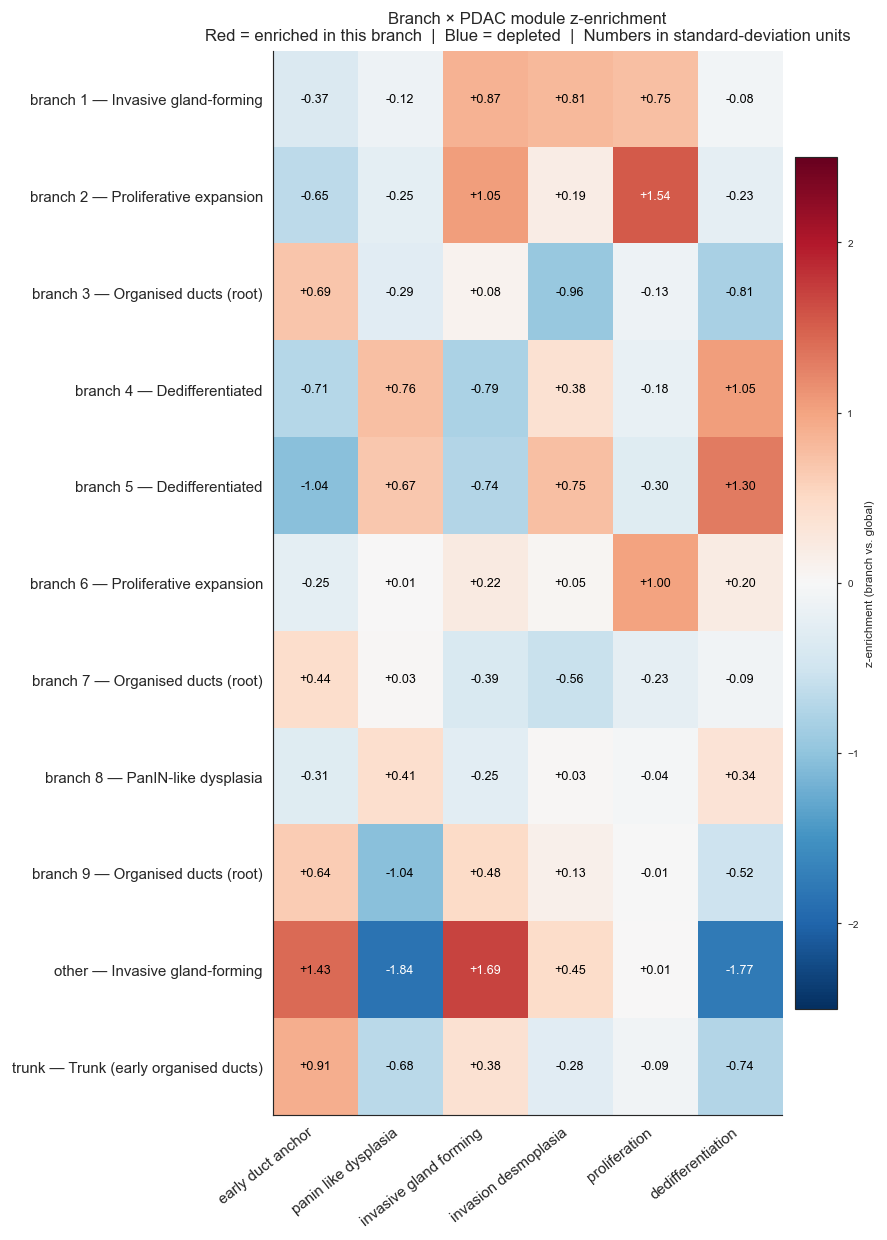


Each cell: (branch median − global median) / global SD.
The dominant module (highest z) determines the biological name assigned above.
Branches with strongly positive values on invasion_desmoplasia_axis mark the invasive front; those enriched on early_duct_anchor_score anchor the trajectory root.


In [31]:
# ── Branch × PDAC module z-enrichment heatmap ────────────────────────────────
# Rows = branches (biologically named); columns = PDAC pathology module scores.
# Colour = z-enrichment: red means the branch median is well above the global
# median; blue means it is below.  Numbers are shown for rapid reading.

_z_cols_plot = [
    c for c in branch_summary_df.columns
    if c.endswith("__z_enrichment")
    and c.replace("__z_enrichment", "") in module_plot_cols
]

if _z_cols_plot and not branch_summary_df.empty:
    hm_df = branch_summary_df.set_index("branch")[_z_cols_plot].copy()
    # Reindex rows so biological names appear on y-axis
    hm_df.index = [branch_bio_names.get(b, str(b)) for b in hm_df.index]
    hm_df.columns = [
        c.replace("__z_enrichment", "")
         .replace("pdac_", "")
         .replace("_score", "")
         .replace("_axis", "")
         .replace("_", " ")
        for c in hm_df.columns
    ]

    _vmax = max(2.5, float(np.nanmax(np.abs(hm_df.values))))
    fig, ax = plt.subplots(
        figsize=(max(6, len(hm_df.columns) * 1.25), max(2.5, len(hm_df) * 0.85 + 1.0))
    )
    im = ax.imshow(hm_df.values, aspect="auto", cmap="RdBu_r", vmin=-_vmax, vmax=_vmax)
    plt.colorbar(im, ax=ax, label="z-enrichment (branch vs. global)", shrink=0.8, pad=0.02)

    ax.set_xticks(range(len(hm_df.columns)))
    ax.set_xticklabels(hm_df.columns, rotation=38, ha="right", fontsize=9)
    ax.set_yticks(range(len(hm_df)))
    ax.set_yticklabels(hm_df.index, fontsize=9)

    for r, c_ in np.ndindex(hm_df.values.shape):
        v = hm_df.values[r, c_]
        if np.isfinite(v):
            ax.text(
                c_, r, f"{v:+.2f}", ha="center", va="center",
                fontsize=7.5,
                color="white" if abs(v) > 1.5 else "black",
                fontweight="bold" if abs(v) > 2.0 else "normal",
            )

    ax.set_title(
        "Branch × PDAC module z-enrichment\n"
        "Red = enriched in this branch  |  Blue = depleted  |  Numbers in standard-deviation units",
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()

    print(
        "\nEach cell: (branch median − global median) / global SD.\n"
        "The dominant module (highest z) determines the biological name assigned above.\n"
        "Branches with strongly positive values on invasion_desmoplasia_axis mark the invasive front;"
        " those enriched on early_duct_anchor_score anchor the trajectory root."
    )
else:
    print("branch_summary_df is empty or no matching z-enrichment columns found; skipping heatmap.")


In [32]:
plot_df_binned = add_branch_time_bins(
    plot_df,
    branch_col="principal_tree_branch",
    pseudotime_col="elpigraph_pseudotime",
    n_bins=3,
    labels=["early", "middle", "late"],
)
branch_time_matrix = branch_time_feature_matrix(
    plot_df_binned,
    feature_cols=module_plot_cols,
    branch_col="principal_tree_branch",
    time_bin_col="branch_time_bin",
)
transition_features_df = find_branch_transition_features(branch_time_matrix, min_abs_delta=0.5)
transition_features_df.to_csv(RESULT_DIR / "branch_time_transition_features.csv", index=False)
transition_features_df.head(20)

,branch,feature,from_bin,to_bin,delta,abs_delta
0,branch 3,pdac_invasion_desmoplasia_axis,early,late,-2.955022,2.955022
1,branch 1,pdac_proliferation_axis,early,late,2.412537,2.412537
2,branch 3,pdac_invasion_desmoplasia_axis,late,middle,2.040869,2.040869
3,branch 6,pdac_proliferation_axis,early,late,1.897398,1.897398
4,branch 6,pdac_proliferation_axis,late,middle,-1.819080,1.819080
5,branch 2,pdac_proliferation_axis,early,late,1.771386,1.771386
6,branch 1,pdac_proliferation_axis,late,middle,-1.619683,1.619683
7,branch 4,pdac_early_duct_anchor_score,early,late,-1.568919,1.568919
8,branch 1,pdac_invasive_gland_forming_score,early,late,1.467427,1.467427
9,branch 4,pdac_invasion_desmoplasia_axis,early,late,1.408891,1.408891


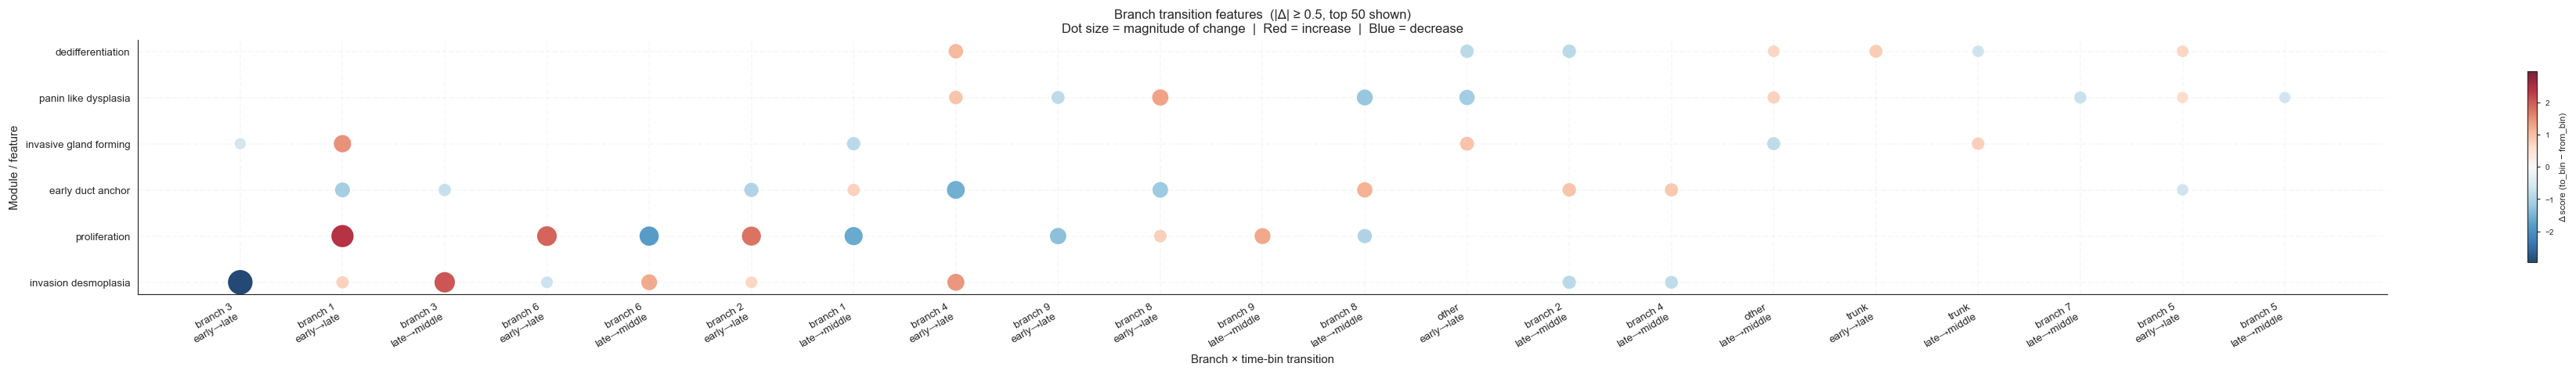


69 total transition events detected (min_abs_delta = 0.5).
Look for features that change strongly in one branch but not others — these are the
branch-defining molecular transitions to highlight in the manuscript.


In [33]:
# ── Transition feature dotplot ────────────────────────────────────────────────
# transition_features_df has columns: branch, feature, from_bin, to_bin,
# delta (late_bin_score − early_bin_score), abs_delta.
# This dotplot shows which module scores change most sharply between adjacent
# branch-time thirds.  Dot size = |Δ|; colour = direction (red = increasing).

if not transition_features_df.empty:
    _tf = transition_features_df.copy()
    _tf["feature_label"] = (
        _tf["feature"]
        .str.replace("pdac_", "", regex=False)
        .str.replace("_score", "", regex=False)
        .str.replace("_axis", "", regex=False)
        .str.replace("_", " ", regex=False)
    )
    _tf["transition"] = _tf["branch"].astype(str) + "\n" + _tf["from_bin"].astype(str) + "→" + _tf["to_bin"].astype(str)

    # Keep top features by abs_delta; de-duplicate by (feature_label, transition)
    top_n = 25
    _tf_top = _tf.nlargest(top_n * 4, "abs_delta").drop_duplicates(["feature_label", "transition"]).head(top_n * 2)

    # Build ordered axes
    ordered_transitions = (
        _tf_top.groupby("transition")["abs_delta"].max()
        .sort_values(ascending=False).index.tolist()
    )
    ordered_features = (
        _tf_top.groupby("feature_label")["abs_delta"].max()
        .sort_values(ascending=False).index.tolist()
    )

    trans_idx = {t: i for i, t in enumerate(ordered_transitions)}
    feat_idx  = {f: i for i, f in enumerate(ordered_features)}

    x_vals = _tf_top["transition"].map(trans_idx)
    y_vals = _tf_top["feature_label"].map(feat_idx)
    sizes  = (_tf_top["abs_delta"] * 120).clip(20, 600)
    colors = _tf_top["delta"]  # positive = red, negative = blue

    fig, ax = plt.subplots(figsize=(max(6, len(ordered_transitions) * 1.5), max(3, len(ordered_features) * 0.5 + 1.0)))
    sc = ax.scatter(
        x_vals, y_vals,
        s=sizes, c=colors, cmap="RdBu_r",
        vmin=-colors.abs().max(), vmax=colors.abs().max(),
        alpha=0.88, edgecolors="none",
    )
    plt.colorbar(sc, ax=ax, label="Δ score (to_bin − from_bin)", shrink=0.75)

    ax.set_xticks(range(len(ordered_transitions)))
    ax.set_xticklabels(ordered_transitions, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(ordered_features)))
    ax.set_yticklabels(ordered_features, fontsize=8)
    ax.set_xlabel("Branch × time-bin transition", fontsize=9)
    ax.set_ylabel("Module / feature", fontsize=9)
    ax.set_title(
        f"Branch transition features  (|Δ| ≥ 0.5, top {len(_tf_top)} shown)\n"
        "Dot size = magnitude of change  |  Red = increase  |  Blue = decrease",
        fontsize=10,
    )
    ax.grid(True, alpha=0.15, linestyle="--")
    fig.tight_layout()
    plt.show()

    print(f"\n{len(transition_features_df)} total transition events detected (min_abs_delta = 0.5).")
    print("Look for features that change strongly in one branch but not others — these are the")
    print("branch-defining molecular transitions to highlight in the manuscript.")
else:
    print("No transition features detected (|Δ| < 0.5 for all branch-time pairs, or too few niches per bin).")


## Surrounding-Niche Changes Along Pseudotime

As ductal niches progress along the trajectory, their immediate microenvironment co-evolves. These plots answer: **does the composition and activation state of the surrounding TME change systematically with niche pseudotime?**

**Expected patterns and their biological meaning:**

*Immune surround:*
- **T cell proportion** — may increase in intermediate pseudotime (immune engagement with dysplastic glands) then decrease in late pseudotime (immune exclusion in deeply desmoplastic invasive niches)
- **B lineage proportion** — may peak at intermediate pseudotime where TLS-like structures form at the tumour margin

*Stromal surround:*
- **Fibroblast proportion** — increases with pseudotime, peaking around invasive glands (desmoplastic reaction)
- **Acinar epithelium proportion** — decreases with pseudotime as normal pancreas is displaced by tumour

*Fibroblast marker expression:*
- **FAP, aSMA** surround levels should increase along the invasion-desmoplasia arm — fibroblasts adjacent to invasive glands are progressively more activated
- **PDPN, Thy1** — more heterogeneous; may peak at a specific branch or transition point

*Ductal marker expression:*
- **CK19, NaKATPase** in surrounding ductal cells — should decrease along the dedifferentiation axis (loss of luminal differentiation markers)
- **Ki67** — may show a non-monotonic pattern, peaking in the proliferative branch

All trends are computed with LOWESS smoothing (`frac=0.3`) to reveal the underlying biological signal through the niche-to-niche noise.

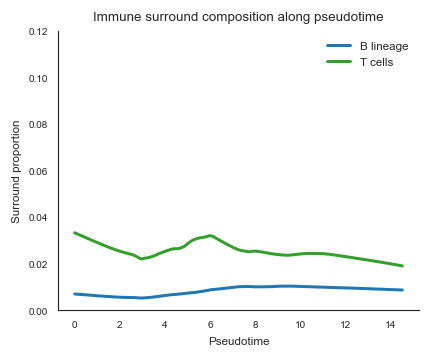

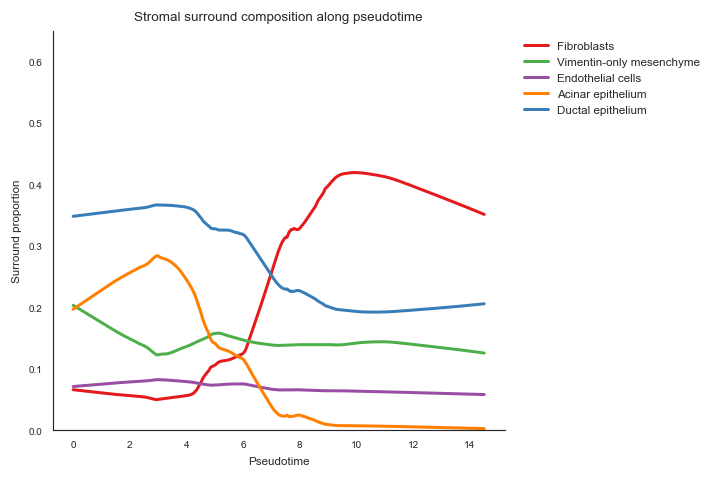

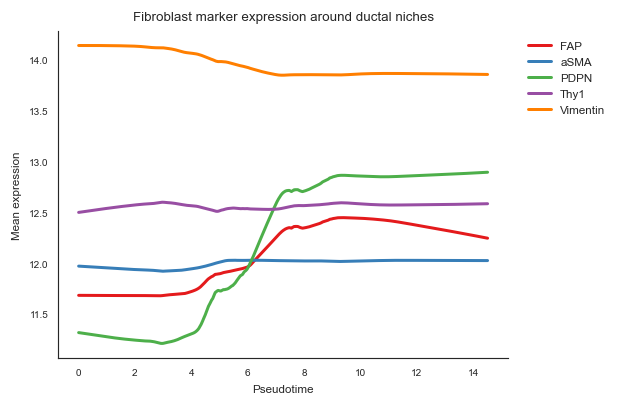

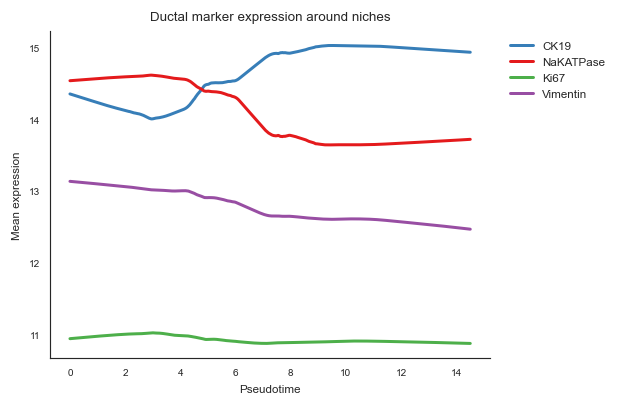

In [34]:
surround_plot_df = surround_context_df.merge(
    niche_result_pathology[[DUCT_NICHE_KEY, "image_id", "elpigraph_pseudotime", "elpigraph_edge_id", "principal_tree_branch"]],
    on=[DUCT_NICHE_KEY, "image_id"],
    how="left",
)

immune_prop_map = {
    "surround_prop__B_lineage": ("B lineage", "#1f78b4"),
    "surround_prop__T_cells": ("T cells", "#33a02c"),
}
stromal_prop_map = {
    "surround_prop__Fibroblasts": ("Fibroblasts", "#e41a1c"),
    "surround_prop__Vimentin_only_mesenchyme": ("Vimentin-only mesenchyme", "#4daf4a"),
    "surround_prop__Endothelial_cells": ("Endothelial cells", "#984ea3"),
    "surround_prop__pancreatic_acinar_epithelium": ("Acinar epithelium", "#ff7f00"),
    "surround_prop__pancreatic_ductal_epithelium": ("Ductal epithelium", "#377eb8"),
}
fibro_marker_map = {
    surround_marker_col("Fibroblasts", "FAP_expr"): ("FAP", "#e41a1c"),
    surround_marker_col("Fibroblasts", "aSMA_expr"): ("aSMA", "#377eb8"),
    surround_marker_col("Fibroblasts", "PDPN_expr"): ("PDPN", "#4daf4a"),
    surround_marker_col("Fibroblasts", "Thy1_expr"): ("Thy1", "#984ea3"),
    surround_marker_col("Fibroblasts", "Vimentin_expr"): ("Vimentin", "#ff7f00"),
}
duct_marker_map = {
    surround_marker_col(DUCT_LABEL, "CK19_expr"): ("CK19", "#377eb8"),
    surround_marker_col(DUCT_LABEL, "NaKATPase_expr"): ("NaKATPase", "#e41a1c"),
    surround_marker_col(DUCT_LABEL, "Ki67_expr"): ("Ki67", "#4daf4a"),
    surround_marker_col(DUCT_LABEL, "Vimentin_expr"): ("Vimentin", "#984ea3"),
}

immune_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    immune_prop_map,
    title="Immune surround composition along pseudotime",
    ylabel="Surround proportion",
    ylim=(0, 0.12),
    figsize=(3.6, 3.0),
)
stromal_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    stromal_prop_map,
    title="Stromal surround composition along pseudotime",
    ylabel="Surround proportion",
    ylim=(0, 0.65),
    figsize=(6.0, 4.0),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)
fibro_marker_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    fibro_marker_map,
    title="Fibroblast marker expression around ductal niches",
    ylabel="Mean expression",
    figsize=(5.2, 3.4),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)
duct_marker_summary_df = plot_lowess_feature_map(
    surround_plot_df,
    duct_marker_map,
    title="Ductal marker expression around niches",
    ylabel="Mean expression",
    figsize=(5.2, 3.4),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)

In [35]:
surround_features = [
    feature
    for feature_map in [immune_prop_map, stromal_prop_map, fibro_marker_map, duct_marker_map]
    for feature in feature_map
    if feature in surround_plot_df.columns
]
surround_specs = [
    {"feature": feature, "label": feature.replace("surround_prop__", "").replace("surround__", ""), "category": "surrounding niche"}
    for feature in surround_features
]
surround_trend_table = compute_feature_trend_table(
    surround_plot_df,
    surround_specs,
    pseudotime_col="elpigraph_pseudotime",
    group_name="PDAC_34434_1_surroundings",
    min_n=15,
)
surround_trend_table.to_csv(RESULT_DIR / "surrounding_context_pseudotime_trends.csv", index=False)
surround_trend_table.head(20)

,group,category,feature,label,n,spearman_r,spearman_p,early_quantile,late_quantile,early_median,late_median,late_minus_early_median,mannwhitney_p_early_vs_late,spearman_fdr,mannwhitney_fdr
0,PDAC_34434_1_surroundings,surrounding niche,surround_prop__Fibroblasts,Fibroblasts,12184,0.621129,0.000000e+00,0.1,0.9,0.048780,0.390977,0.342197,0.000000e+00,0.000000e+00,0.000000e+00
1,PDAC_34434_1_surroundings,surrounding niche,surround__Fibroblasts__PDPN_expr__mean,Fibroblasts__PDPN_expr__mean,12006,0.592290,0.000000e+00,0.1,0.9,11.269585,12.882423,1.612837,7.732798e-277,0.000000e+00,3.093119e-276
2,PDAC_34434_1_surroundings,surrounding niche,surround__pancreatic_ductal_epithelium__CK19_e...,pancreatic_ductal_epithelium__CK19_expr__mean,12157,0.545001,0.000000e+00,0.1,0.9,14.340757,15.041301,0.700544,6.726656e-219,0.000000e+00,2.152530e-218
3,PDAC_34434_1_surroundings,surrounding niche,surround__Fibroblasts__FAP_expr__mean,Fibroblasts__FAP_expr__mean,12006,0.521611,0.000000e+00,0.1,0.9,11.715408,12.398131,0.682722,1.879362e-216,0.000000e+00,5.011632e-216
4,PDAC_34434_1_surroundings,surrounding niche,surround_prop__B_lineage,B_lineage,12184,0.213365,1.889526e-125,0.1,0.9,0.004892,0.010381,0.005488,4.960922e-28,3.023242e-125,7.937475e-28
5,PDAC_34434_1_surroundings,surrounding niche,surround__Fibroblasts__aSMA_expr__mean,Fibroblasts__aSMA_expr__mean,12006,0.189497,1.816805e-97,0.1,0.9,11.961214,12.024145,0.062931,3.499010e-22,2.642626e-97,5.089470e-22
6,PDAC_34434_1_surroundings,surrounding niche,surround__Fibroblasts__Thy1_expr__mean,Fibroblasts__Thy1_expr__mean,12006,0.010645,2.434998e-01,0.1,0.9,12.503109,12.548904,0.045795,1.038831e-02,2.434998e-01,1.038831e-02
7,PDAC_34434_1_surroundings,surrounding niche,surround_prop__T_cells,T_cells,12184,-0.017379,5.507780e-02,0.1,0.9,0.028653,0.021645,-0.007008,9.003766e-09,5.874965e-02,9.604017e-09
8,PDAC_34434_1_surroundings,surrounding niche,surround_prop__Vimentin_only_mesenchyme,Vimentin_only_mesenchyme,12184,-0.036086,6.775055e-05,0.1,0.9,0.184887,0.137825,-0.047062,3.374830e-17,7.742919e-05,4.499773e-17
9,PDAC_34434_1_surroundings,surrounding niche,surround__pancreatic_ductal_epithelium__Ki67_e...,pancreatic_ductal_epithelium__Ki67_expr__mean,12157,-0.152704,2.499803e-64,0.1,0.9,10.955633,10.910033,-0.045600,4.129670e-10,3.076680e-64,4.719623e-10


### Branch Surround Composition Heatmap

Rows = principal tree branches; columns = surrounding cell type proportions.
Colour = across-branch z-score (red = enriched, blue = depleted).
Complements the LOWESS trend plots by showing which branches are structurally
distinct in their microenvironment.


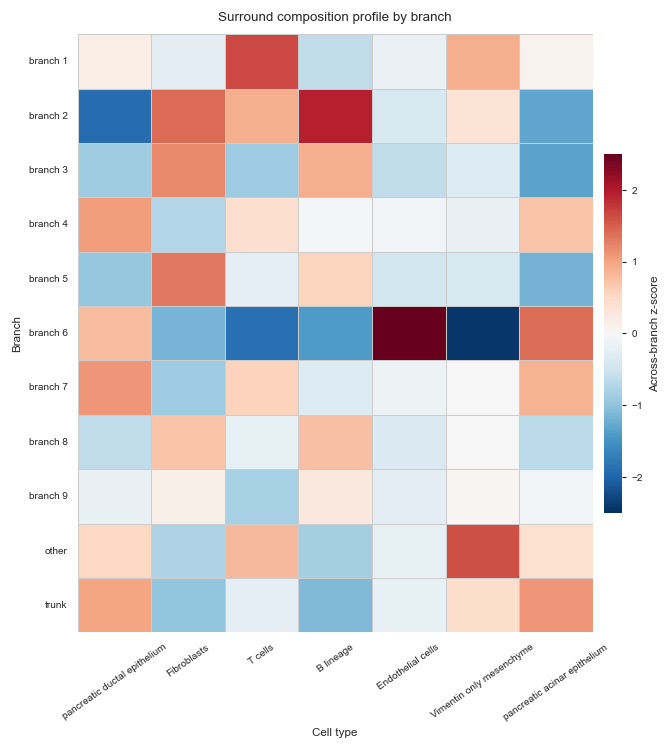

,pancreatic ductal epithelium,Fibroblasts,T cells,B lineage,Endothelial cells,Vimentin only mesenchyme,pancreatic acinar epithelium
principal_tree_branch,,,,,,,
branch 1,0.189072,-0.272530,1.658453,-0.637762,-0.172883,0.912239,0.110870
branch 2,-1.924005,1.410367,0.903163,1.936824,-0.411172,0.351240,-1.322124
branch 3,-0.884346,1.207133,-0.917169,0.912249,-0.625259,-0.350317,-1.332744
branch 4,1.040944,-0.733219,0.421291,-0.055489,-0.085362,-0.178490,0.709099
branch 5,-0.966387,1.320411,-0.245828,0.556148,-0.480649,-0.421278,-1.176037
branch 6,0.762402,-1.152955,-1.893203,-1.416756,2.974452,-2.435677,1.393648
branch 7,1.103105,-0.898466,0.567869,-0.348122,-0.122878,0.014444,0.878679
branch 8,-0.627893,0.706145,-0.218148,0.750938,-0.387786,0.003554,-0.679326
branch 9,-0.195053,0.154269,-0.829152,0.256825,-0.254321,0.052411,-0.093694


In [36]:
# ── Branch × surround composition heatmap ───────────────────────────────────
# [reason] The LOWESS trend plots show temporal dynamics; this heatmap shows
# which branches are most enriched for each cell type, matching the combined
# notebook (combined cell 32) for cross-experiment consistency.

_surround_heatmap_cols = [
    c for c in [
        "surround_prop__pancreatic_ductal_epithelium",
        "surround_prop__Fibroblasts",
        "surround_prop__T_cells",
        "surround_prop__B_lineage",
        "surround_prop__Endothelial_cells",
        "surround_prop__Vimentin_only_mesenchyme",
        "surround_prop__pancreatic_acinar_epithelium",
    ] if c in surround_plot_df.columns
]

_branch_col = "principal_tree_branch"
_branch_surround = (
    surround_plot_df.groupby(_branch_col, observed=True)[_surround_heatmap_cols]
    .mean()
    .dropna(how="all")
)
# z-score across branches
_branch_surround_z = (
    (_branch_surround - _branch_surround.mean()) / _branch_surround.std().replace(0, 1)
)
_branch_surround_z.columns = [
    c.replace("surround_prop__","").replace("_"," ") for c in _branch_surround_z.columns
]
_n_branches = _branch_surround_z.shape[0]

fig, ax = plt.subplots(figsize=(5.5, 0.45 * _n_branches + 1.2))
import seaborn as sns
sns.heatmap(
    _branch_surround_z,
    cmap="RdBu_r",
    center=0,
    vmin=-2.5, vmax=2.5,
    linewidths=0.3,
    linecolor="#cccccc",
    annot=False,
    ax=ax,
    cbar_kws={"shrink": 0.6, "label": "Across-branch z-score",
               "fraction": 0.04, "pad": 0.02},
)
ax.set_title("Surround composition profile by branch", fontsize=8, pad=8)
ax.set_xlabel("Cell type", fontsize=7)
ax.set_ylabel("Branch", fontsize=7)
ax.tick_params(axis="x", rotation=35, labelsize=6)
ax.tick_params(axis="y", rotation=0, labelsize=6)
plt.tight_layout(pad=0.5)
plt.savefig(RESULT_DIR / "fig_branch_surround_heatmap.pdf")
plt.show()
_branch_surround_z


### Branch Fibroblast Activation Heatmap

Each row is a principal tree branch; columns are fibroblast activation markers
(FAP = myofibroblast/cancer-associated, aSMA = contractile, PDPN = progenitor,
Thy1 = quiescent). Reveals which branches carry the most pro-tumourigenic
stromal niche.


In [37]:
# ── Branch × fibroblast activation heatmap ──────────────────────────────────
# [reason] Complements combined notebook cell 33; exposes branch-level
# differences in fibroblast activation state within this single PDAC sample.

_fibro_heatmap_cols = [
    c for c in [
        "surround__Fibroblasts__FAP_expr_z__mean",
        "surround__Fibroblasts__aSMA_expr_z__mean",
        "surround__Fibroblasts__PDPN_expr_z__mean",
        "surround__Fibroblasts__Thy1_expr_z__mean",
    ] if c in surround_plot_df.columns
]

if _fibro_heatmap_cols:
    _branch_fibro = (
        surround_plot_df.groupby(_branch_col, observed=True)[_fibro_heatmap_cols]
        .mean()
        .dropna(how="all")
    )
    _branch_fibro_z = (
        (_branch_fibro - _branch_fibro.mean()) / _branch_fibro.std().replace(0, 1)
    )
    _branch_fibro_z.columns = [
        c.replace("surround__Fibroblasts__","Fibroblasts: ")
         .replace("_expr_z__mean","") for c in _branch_fibro_z.columns
    ]

    fig, ax = plt.subplots(figsize=(3.8, 0.45 * _branch_fibro_z.shape[0] + 1.2))
    sns.heatmap(
        _branch_fibro_z,
        cmap="RdBu_r",
        center=0,
        vmin=-2.5, vmax=2.5,
        linewidths=0.3,
        linecolor="#cccccc",
        annot=True,
        fmt=".2f",
        annot_kws={"size": 5.5},
        ax=ax,
        cbar_kws={"shrink": 0.6, "label": "Across-branch z-score",
                   "fraction": 0.06, "pad": 0.02},
    )
    ax.set_title("Fibroblast activation context by branch", fontsize=8, pad=8)
    ax.set_xlabel("Marker", fontsize=7)
    ax.set_ylabel("Branch", fontsize=7)
    ax.tick_params(axis="x", rotation=30, labelsize=6)
    ax.tick_params(axis="y", rotation=0, labelsize=6)
    plt.tight_layout(pad=0.5)
    plt.savefig(RESULT_DIR / "fig_branch_fibro_heatmap.pdf")
    plt.show()
    display(_branch_fibro_z.round(3))
else:
    print("No fibroblast marker columns found in surround_plot_df — skipping heatmap.")


No fibroblast marker columns found in surround_plot_df — skipping heatmap.


## Tier B Surrounding Subpopulations

Tier B resolves immune phenotypes into functionally distinct subsets. This matters because the *composition* of the immune surround — not just total T cell or B cell fraction — determines the immune functional state around each niche.

**T cell subsets to watch:**
- **Cytotoxic CD8 T cells** — direct tumour-killing capacity; if they decrease with pseudotime, it suggests progressive immune exclusion as glands become more invasive and desmoplastic
- **Tregs** — immunosuppressive; enrichment around late-pseudotime invasive glands would implicate active immune escape
- **Activated CD4/CD8 T cells** — may peak at intermediate pseudotime around dysplastic but not yet deeply desmoplastic niches

**B cell subsets:**
- **Plasmablast-like cells** — active antibody secretors; their spatial proximity to specific niche states may reveal the pseudotime at which humoral immunity engages
- **Memory B cells** — may form TLS-like structures; their proportion around specific niche states would localise TLS formation in the trajectory
- **PDL1+ B cells** — regulatory B cell-like cells with immunosuppressive potential

In [38]:
tier_b_labels = (
    adata.obs["Tier_B"]
    .value_counts()
    .loc[lambda values: ~values.index.isin(["noise", "Unknown"])]
    .index.tolist()
)

surround_context_df_B = sv.summarize_niche_surrounding_context(
    adata,
    niche_key=DUCT_NICHE_KEY,
    phenotype_key="Tier_B",
    phenotype_labels=tier_b_labels,
    surround_hops=5,
)
surround_plot_df_B = surround_context_df_B.merge(
    niche_result_pathology[[DUCT_NICHE_KEY, "image_id", "elpigraph_pseudotime", "elpigraph_edge_id", "principal_tree_branch"]],
    on=[DUCT_NICHE_KEY, "image_id"],
    how="left",
)
surround_plot_df_B.head()

,pancreatic ductal epithelium_mask_component,image_id,n_cells,n_surround,surround__hop_1__n_cells,surround__hop_2__n_cells,surround__hop_3__n_cells,surround__hop_4__n_cells,surround__hop_5__n_cells,surround_prop__pancreatic_ductal_epithelium,...,surround__PDL1__B_cells__n_cells,surround_prop__plasmablasts,surround__plasmablasts__n_cells,surround_prop__B_lineage,surround__B_lineage__n_cells,surround_prop__Tfh_like_cells,surround__Tfh_like_cells__n_cells,elpigraph_pseudotime,elpigraph_edge_id,principal_tree_branch
0,global__component_0,34434_1,8.0,169.0,23.0,31.0,30.0,33.0,52.0,0.106509,...,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,5.028596,25.0,branch 9
1,global__component_1,34434_1,104.0,1088.0,171.0,197.0,227.0,247.0,246.0,0.271140,...,2.0,0.000000,0.0,0.003676,4.0,0.0,0.0,6.100563,13.0,branch 4
2,global__component_10,34434_1,25.0,926.0,106.0,129.0,178.0,230.0,283.0,0.281857,...,1.0,0.000000,0.0,0.001080,1.0,0.0,0.0,4.432438,15.0,branch 1
3,global__component_100,34434_1,28.0,914.0,86.0,142.0,194.0,233.0,259.0,0.243982,...,1.0,0.002188,2.0,0.000000,0.0,0.0,0.0,6.575854,24.0,branch 7
4,global__component_1000,34434_1,10.0,827.0,39.0,95.0,160.0,246.0,287.0,0.437727,...,0.0,0.001209,1.0,0.000000,0.0,0.0,0.0,0.838807,18.0,trunk


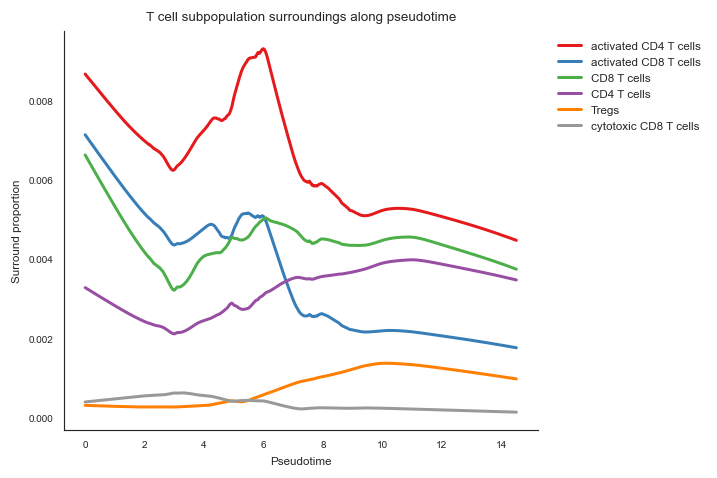

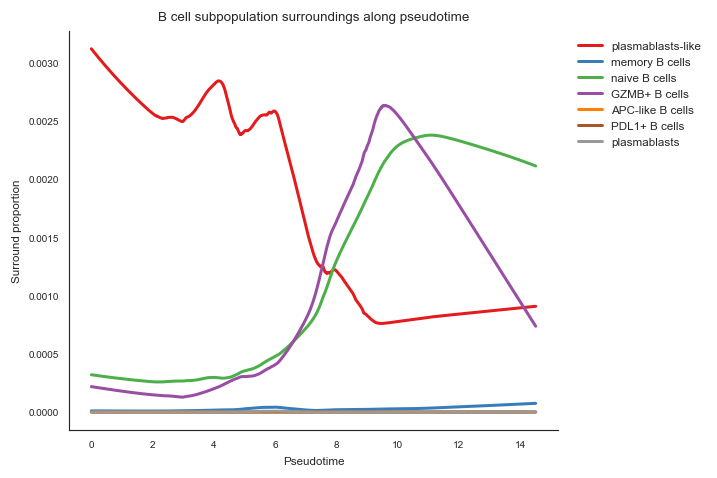

,feature,label
0,surround_prop__plasmablasts_like,plasmablasts-like
1,surround_prop__memory_B_cells,memory B cells
2,surround_prop__naive_B_cells,naive B cells
3,surround_prop__GZMB__B_cells,GZMB+ B cells
4,surround_prop__APC_like_B_cells,APC-like B cells
5,surround_prop__PDL1__B_cells,PDL1+ B cells
6,surround_prop__plasmablasts,plasmablasts


In [39]:
t_cell_prop_map = {
    "surround_prop__activated_CD4_T_cells": ("activated CD4 T cells", "#e41a1c"),
    "surround_prop__activated_CD8_T_cells": ("activated CD8 T cells", "#377eb8"),
    "surround_prop__CD8_T_cells": ("CD8 T cells", "#4daf4a"),
    "surround_prop__CD4_T_cells": ("CD4 T cells", "#984ea3"),
    "surround_prop__Tregs": ("Tregs", "#ff7f00"),
    "surround_prop__Th2-like_cells": ("Th2-like", "#a65628"),
    "surround_prop__cytotoxic_CD8_T_cells": ("cytotoxic CD8 T cells", "#999999"),
}
b_cell_prop_map = {
    "surround_prop__plasmablasts_like": ("plasmablasts-like", "#e41a1c"),
    "surround_prop__memory_B_cells": ("memory B cells", "#377eb8"),
    "surround_prop__naive_B_cells": ("naive B cells", "#4daf4a"),
    "surround_prop__GZMB__B_cells": ("GZMB+ B cells", "#984ea3"),
    "surround_prop__APC_like_B_cells": ("APC-like B cells", "#ff7f00"),
    "surround_prop__PDL1__B_cells": ("PDL1+ B cells", "#a65628"),
    "surround_prop__plasmablasts": ("plasmablasts", "#999999"),
}

plot_lowess_feature_map(
    surround_plot_df_B,
    t_cell_prop_map,
    title="T cell subpopulation surroundings along pseudotime",
    ylabel="Surround proportion",
    figsize=(6, 4),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)
plot_lowess_feature_map(
    surround_plot_df_B,
    b_cell_prop_map,
    title="B cell subpopulation surroundings along pseudotime",
    ylabel="Surround proportion",
    figsize=(6, 4),
    legend_loc="upper left",
    legend_bbox=(1.02, 1.0),
)

## Cell-Cell Interaction Dynamics

`compute_epithelial_centered_interaction_dynamics` quantifies, for each ductal cell at each pseudotime bin, **how many target cells (fibroblasts, immune cells) are within 30 µm**. `summarize_epithelial_interaction_dynamics` aggregates to pseudotime bins, giving:

- `mean_target_neighbor_excess`: how many more target cells are in proximity than expected from random mixing at that pseudotime stage
- `fraction_source_with_target_neighbor`: what fraction of ductal cells have at least one target cell within 30 µm
- `hotspot_fraction`: fraction of ductal cells qualifying as a cross-Ripley hotspot (local density exceeds random expectation)

**This is distinct from the surrounding-context analysis**: the cell graph surround (5 hops, ≈150 µm) captures the regional composition of the TME, while this interaction analysis captures **direct physical proximity** (30 µm, 1–2 cell diameters). Short-range interactions are most relevant for direct juxtacrine and close paracrine signalling.

**Branch-stratified dynamics**: interactions are computed both globally (all ductal cells) and separately per trajectory branch, revealing whether the same stromal or immune associations apply uniformly across the trajectory or are concentrated in specific progression arms.

**Summary heatmap**: a single compact heatmap pools all target phenotypes across pseudotime bins so patterns are immediately comparable — one row per target, one column per bin.

**Expected patterns:**
- **Fibroblast proximity** — increases with pseudotime (desmoplastic reaction physically envelops more advanced glands); `mean_target_neighbor_excess` for fibroblasts should be positive and rising along the invasion arm
- **T cell proximity** — a decrease at late pseudotime would support the immune desert model of PDAC
- **B cell proximity** — likely peaks at intermediate pseudotime, near niches with TLS proximity

These dynamics, paired with surrounding context and module trends, form the core evidence base for the manuscript's claim about **co-evolution of tumour architecture and the microenvironment** along the PDAC niche trajectory.


In [40]:
# ── Helper: compute and summarise interaction dynamics ───────────────────────
def _run_interaction(phenotype_key, targets, output_prefix):
    """Compute epithelial-centred interaction dynamics; returns (cell_df, bin_df)."""
    _valid = [t for t in targets if t in set(adata.obs[phenotype_key].dropna().astype(str))]
    if not _valid:
        print(f"  No requested targets found in adata.obs[{phenotype_key!r}].")
        return pd.DataFrame(), pd.DataFrame()

    _cell_df = sv.compute_epithelial_centered_interaction_dynamics(
        adata,
        pseudotime_key="elpigraph_pseudotime_pathology",
        phenotype_key=phenotype_key,
        target_phenotypes=_valid,
        source_phenotype=DUCT_LABEL,
        radius_um=30,
        pixel_size_um=PIXEL_SIZE_UM,
        pseudotime_bin_count=10,
    )
    _bin_df = sv.summarize_epithelial_interaction_dynamics(
        _cell_df,
        pseudotime_key="elpigraph_pseudotime_pathology",
    )
    _cell_df.to_csv(RESULT_DIR / f"{output_prefix}_interaction_cells.csv", index=False)
    _bin_df.to_csv(RESULT_DIR / f"{output_prefix}_interaction_bins.csv", index=False)
    return _cell_df, _bin_df


# ── Helper: branch-stratified interaction summary ────────────────────────────
def _branch_stratified_interaction(cell_df, bin_label=""):
    """Re-summarize interaction_df split by trajectory branch."""
    if cell_df.empty or "principal_tree_branch_pathology" not in adata.obs.columns:
        return pd.DataFrame()
    # Merge branch labels onto the per-cell interaction dataframe
    branch_map = adata.obs[["principal_tree_branch_pathology"]].copy()
    branch_map.index.name = "cell_id"
    branch_map = branch_map.reset_index().rename(columns={"index": "cell_id"})
    merged = cell_df.merge(branch_map, on="cell_id", how="left")

    summaries = []
    for branch, grp in merged.groupby("principal_tree_branch_pathology", dropna=True):
        _s = sv.summarize_epithelial_interaction_dynamics(
            grp, pseudotime_key="elpigraph_pseudotime_pathology"
        )
        _s.insert(0, "branch", branch)
        _s["branch_bio_name"] = branch_bio_names.get(branch, str(branch))
        summaries.append(_s)
    if not summaries:
        return pd.DataFrame()
    out = pd.concat(summaries, ignore_index=True)
    if bin_label:
        print(f"  Branch-stratified summary ({bin_label}): {len(out)} rows across {out['branch'].nunique()} branches.")
    return out


# ── Compact heatmap: target × pseudotime bin ─────────────────────────────────
def _compact_interaction_heatmap(bin_df, value_col="fraction_source_with_target_neighbor",
                                  title="Interaction dynamics heatmap",
                                  target_col="target_phenotype", bin_col="pseudotime_bin"):
    """
    One row per target phenotype, one column per pseudotime bin.
    Value can be 'fraction_source_with_target_neighbor', 'mean_target_neighbor_excess',
    or 'hotspot_fraction'.
    """
    if bin_df.empty:
        print(f"  Skipping heatmap ({title}) — data is empty.")
        return

    pivot = (
        bin_df.groupby([target_col, bin_col])[value_col]
        .mean()
        .unstack(bin_col)
        .sort_index()
    )
    # Sort rows by peak-bin position so related phenotypes cluster
    if not pivot.empty:
        pivot = pivot.loc[pivot.idxmax(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(max(7, pivot.shape[1] * 0.9), max(2.5, pivot.shape[0] * 0.55 + 1.0)))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd", vmin=0)
    plt.colorbar(im, ax=ax, label=value_col.replace("_", " "), shrink=0.8)

    ax.set_xticks(range(pivot.shape[1]))
    ax.set_xticklabels([f"bin {b}" for b in pivot.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(pivot.shape[0]))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_xlabel("Pseudotime bin  (early → late)", fontsize=9)
    ax.set_title(title, fontsize=10)
    fig.tight_layout()
    plt.show()


In [41]:
# ── Run all interaction analyses ─────────────────────────────────────────────
print("Computing Tier A (Fibroblasts / T cells / B lineage) interactions …")
ia_tier_a_cells, ia_tier_a_bins = _run_interaction(
    "Tier_A",
    targets=["Fibroblasts", "T cells", "B lineage"],
    output_prefix="tier_a",
)

print("Computing Tier B T-cell subset interactions …")
ia_t_cells, ia_t_bins = _run_interaction(
    "Tier_B",
    targets=[
        "activated CD4 T cells", "activated CD8 T cells", "CD8 T cells", "CD4 T cells",
        "Tregs", "Th2-like cells", "cytotoxic CD8 T cells",
    ],
    output_prefix="tier_b_t_cells",
)

print("Computing Tier B B-cell subset interactions …")
ia_b_cells, ia_b_bins = _run_interaction(
    "Tier_B",
    targets=[
        "plasmablasts-like", "memory B cells", "naive B cells", "GZMB+ B cells",
        "APC-like B cells", "PDL1+ B cells", "plasmablasts",
    ],
    output_prefix="tier_b_b_cells",
)

# ── Branch-stratified summaries ───────────────────────────────────────────────
print("\nBuilding branch-stratified interaction summaries …")
ia_tier_a_branches = _branch_stratified_interaction(ia_tier_a_cells, "Tier A")
ia_t_branches      = _branch_stratified_interaction(ia_t_cells,      "T cells")
ia_b_branches      = _branch_stratified_interaction(ia_b_cells,      "B cells")

for _name, _df in [("tier_a_branch_stratified", ia_tier_a_branches),
                   ("tier_b_t_branch_stratified", ia_t_branches),
                   ("tier_b_b_branch_stratified", ia_b_branches)]:
    if not _df.empty:
        _df.to_csv(RESULT_DIR / f"{_name}_interaction_bins.csv", index=False)

print("Done.")


Computing Tier A (Fibroblasts / T cells / B lineage) interactions …
Computing Tier B T-cell subset interactions …
Computing Tier B B-cell subset interactions …

Building branch-stratified interaction summaries …
  Branch-stratified summary (Tier A): 117 rows across 11 branches.
  Branch-stratified summary (T cells): 273 rows across 11 branches.
  Branch-stratified summary (B cells): 273 rows across 11 branches.
Done.


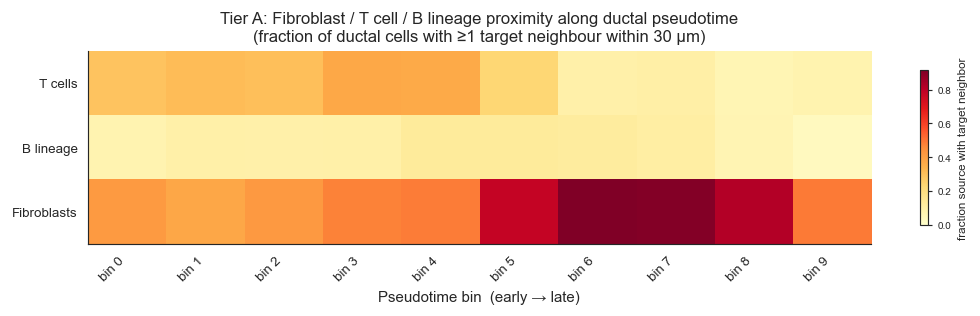

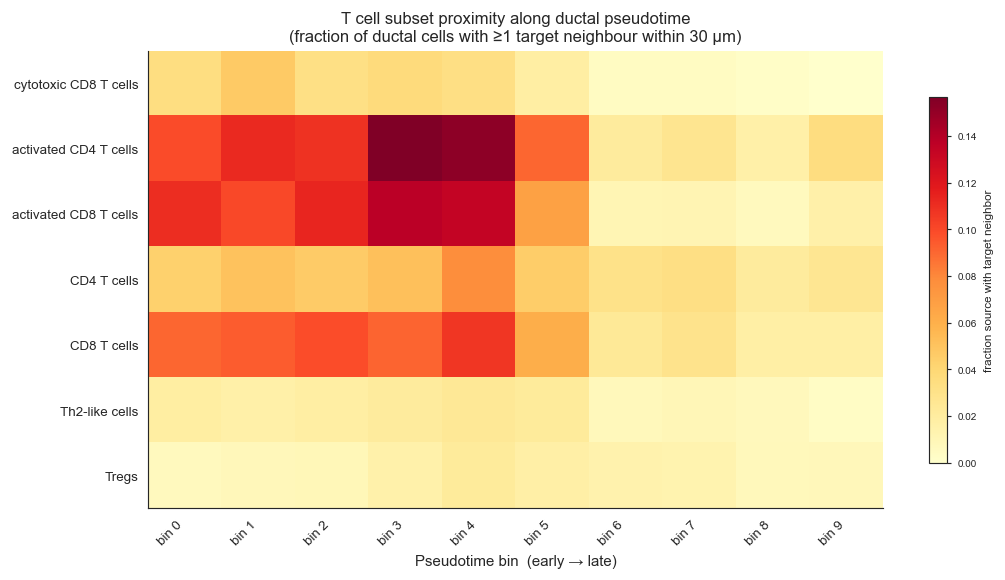

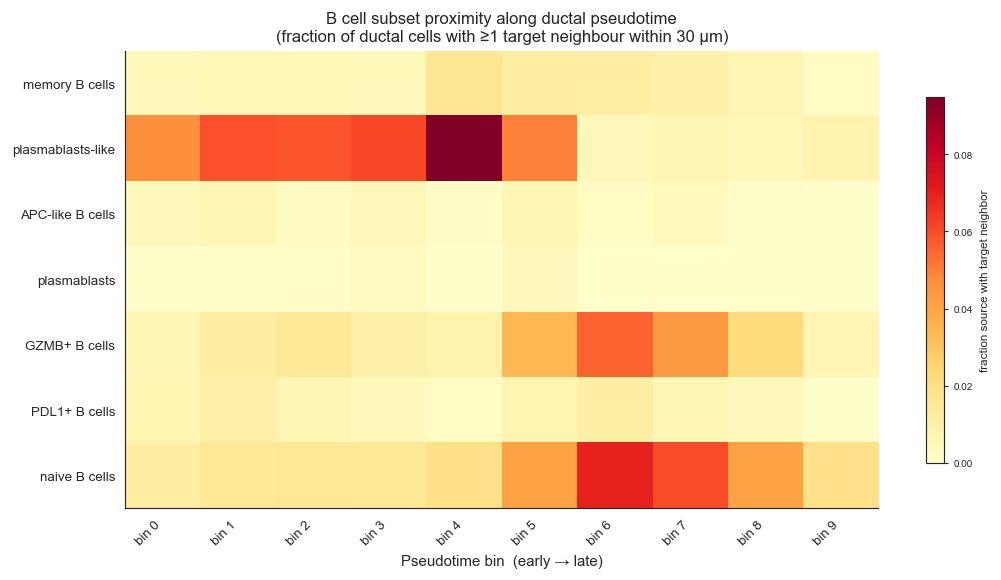

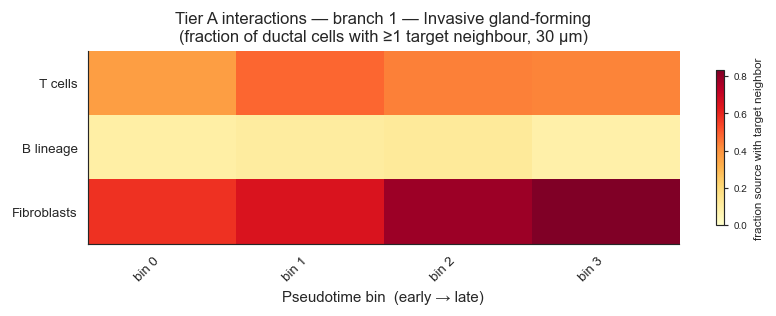

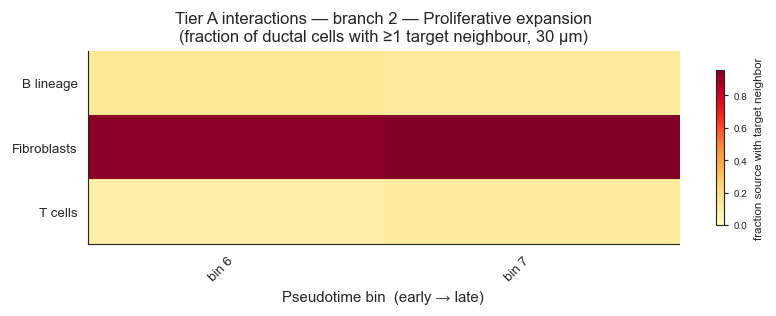

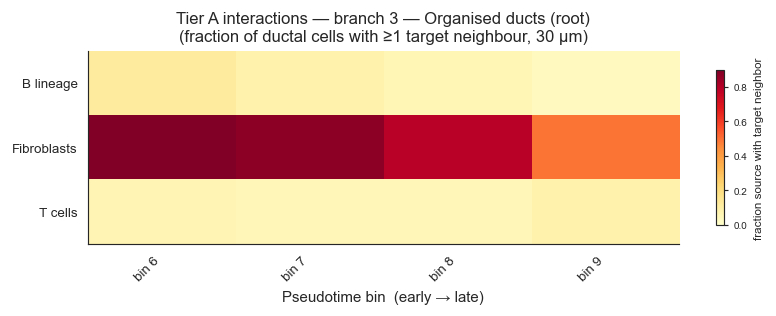

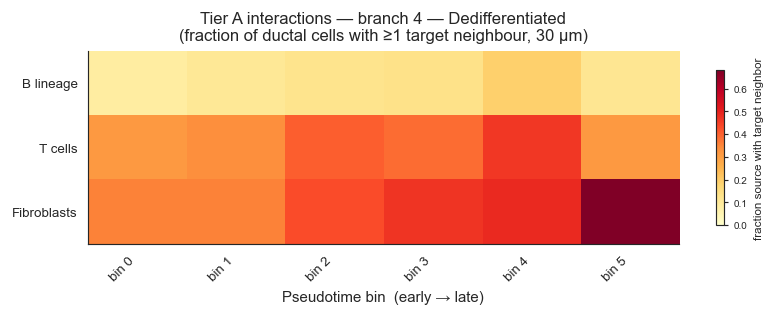

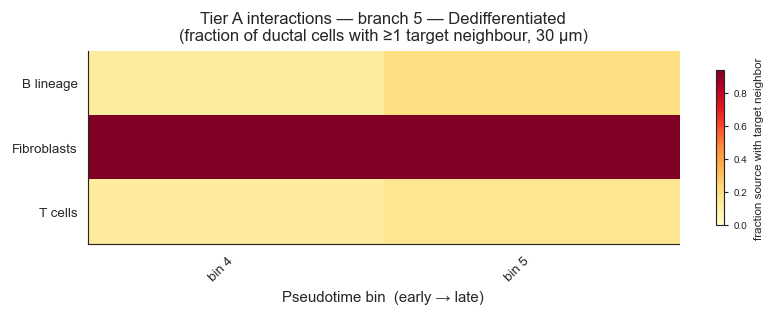

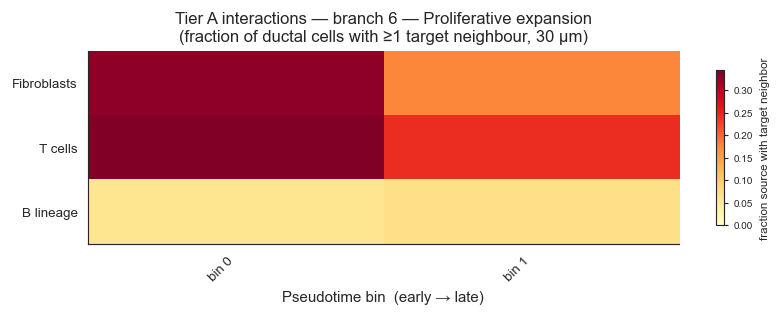

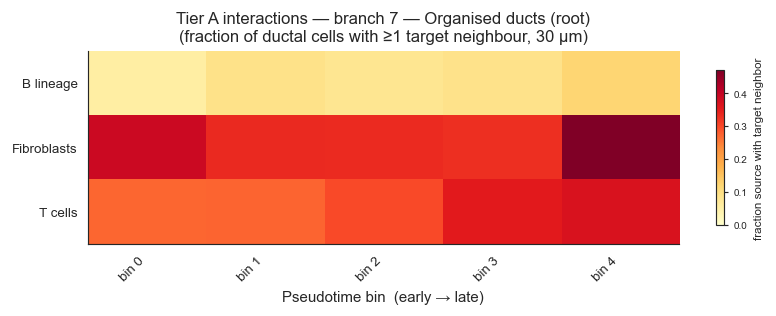

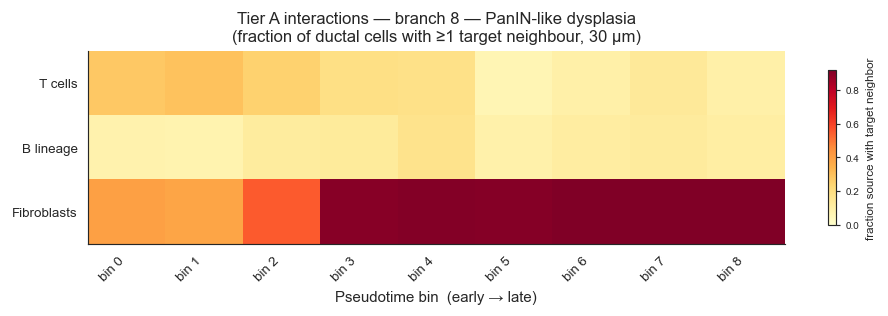

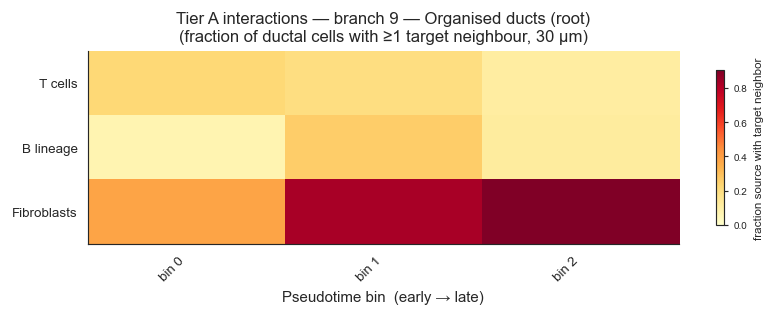

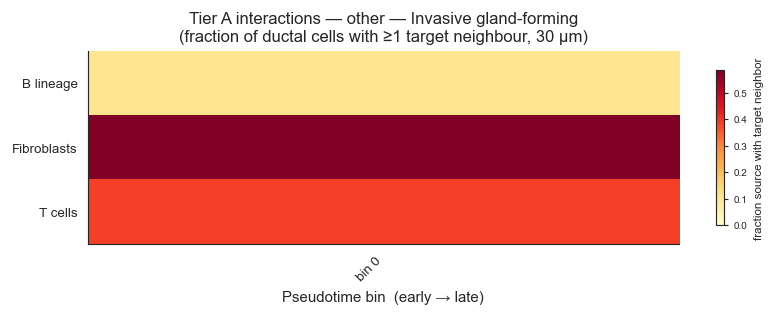

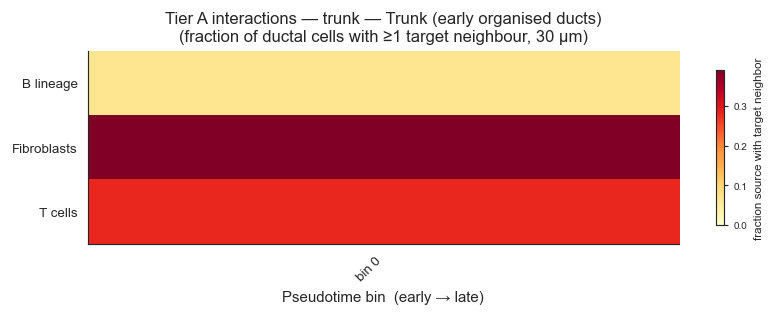


Heatmap read-out for manuscript:
  • Columns that are consistently warm (yellow→red) across fibroblast rows = desmoplastic co-localisation
  • T cell rows that cool at late bins = progressive immune exclusion
  • Rows that peak at intermediate bins = candidate TLS-adjacent or transitional niches
  Branch-stratified panels reveal whether immune inclusion/exclusion is uniform or arm-specific.


In [42]:
# ── Compact target × pseudotime-bin interaction heatmaps ─────────────────────
# Three heatmaps replace the old per-target line plots:
#   (a) Tier A: Fibroblasts / T cells / B lineage
#   (b) T cell subsets
#   (c) B cell subsets
# Within each panel: rows = target phenotypes sorted by peak-proximity bin;
# columns = pseudotime bins (early → late); colour = fraction of ductal cells
# with ≥1 target neighbour within 30 µm.

_value_col = "fraction_source_with_target_neighbor"

_compact_interaction_heatmap(
    ia_tier_a_bins, value_col=_value_col,
    title="Tier A: Fibroblast / T cell / B lineage proximity along ductal pseudotime\n(fraction of ductal cells with ≥1 target neighbour within 30 µm)",
)
_compact_interaction_heatmap(
    ia_t_bins, value_col=_value_col,
    title="T cell subset proximity along ductal pseudotime\n(fraction of ductal cells with ≥1 target neighbour within 30 µm)",
)
_compact_interaction_heatmap(
    ia_b_bins, value_col=_value_col,
    title="B cell subset proximity along ductal pseudotime\n(fraction of ductal cells with ≥1 target neighbour within 30 µm)",
)

# ── Branch-stratified heatmap: Tier A, per-branch view ───────────────────────
if not ia_tier_a_branches.empty:
    for _branch in ia_tier_a_branches["branch"].unique():
        _sub = ia_tier_a_branches[ia_tier_a_branches["branch"] == _branch]
        _bio = branch_bio_names.get(_branch, str(_branch))
        _compact_interaction_heatmap(
            _sub, value_col=_value_col,
            title=f"Tier A interactions — {_bio}\n(fraction of ductal cells with ≥1 target neighbour, 30 µm)",
        )

# ── Manuscript interpretation note ───────────────────────────────────────────
print(
    "\nHeatmap read-out for manuscript:\n"
    "  • Columns that are consistently warm (yellow→red) across fibroblast rows = desmoplastic co-localisation\n"
    "  • T cell rows that cool at late bins = progressive immune exclusion\n"
    "  • Rows that peak at intermediate bins = candidate TLS-adjacent or transitional niches\n"
    "  Branch-stratified panels reveal whether immune inclusion/exclusion is uniform or arm-specific."
)


## Export Summary Tables

All derived tables are written to `notebooks/results/pseudotime_exp2/` for downstream figure generation and manuscript preparation.

| File | Contents | Used for |
|---|---|---|
| `pathology_feature_table_with_modules.csv` | Per-niche feature + module scores | Feature heatmaps, module distribution figures |
| `niche_pseudotime_results.csv` | Per-niche pseudotime, branch, UMAP coords | Trajectory figures, supplementary tables |
| `pca_explained_variance.csv` | PC-wise and cumulative variance (block-compressed PCA) | Methods: dimensionality reduction reporting |
| `pdac_module_pseudotime_trends.csv` | Spearman stats for module trends | Results table (rho, p-value, FDR) |
| `module_nonlinear_trend_shapes.csv` | Quadratic R², peak pseudotime, trend shape per module | Non-linear trend reporting; figure captions |
| `surrounding_context_pseudotime_trends.csv` | Spearman stats for TME composition trends | Results table for immune/stromal co-evolution |
| `branch_summary.csv` | Per-branch module score summaries | Branch × module heatmap, biological naming |
| `branch_time_transition_features.csv` | Largest module shifts between branch-time thirds | Transition feature dotplot |
| `pseudotime_feature_blocks.csv` | Feature block assignments | Methods: feature selection transparency |
| `pseudotime_feature_diagnostics.csv` | NA rates, correlation pruning log | Supplementary methods |
| `tier_a_interaction_bins.csv` | Tier A per-bin interaction summary | Interaction heatmap (global) |
| `tier_a_branch_stratified_interaction_bins.csv` | Fibroblast/immune per branch per bin | Branch-specific desmoplastic co-evolution |
| `tier_b_t_branch_stratified_interaction_bins.csv` | T cell subsets per branch per bin | Branch-stratified immune exclusion |
| `tier_b_b_branch_stratified_interaction_bins.csv` | B cell subsets per branch per bin | Branch-stratified B cell proximity |


In [43]:
summary_paths = {
    "pathology_feature_table":             RESULT_DIR / "pathology_feature_table_with_modules.csv",
    "niche_pseudotime_results":            RESULT_DIR / "niche_pseudotime_results.csv",
    "pca_explained_variance":              RESULT_DIR / "pca_explained_variance.csv",
    "module_trends":                       RESULT_DIR / "pdac_module_pseudotime_trends.csv",
    "module_nonlinear_trend_shapes":       RESULT_DIR / "module_nonlinear_trend_shapes.csv",
    "surrounding_trends":                  RESULT_DIR / "surrounding_context_pseudotime_trends.csv",
    "branch_summary":                      RESULT_DIR / "branch_summary.csv",
    "branch_transition_features":          RESULT_DIR / "branch_time_transition_features.csv",
    "feature_blocks":                      RESULT_DIR / "pseudotime_feature_blocks.csv",
    "feature_diagnostics":                 RESULT_DIR / "pseudotime_feature_diagnostics.csv",
    "tier_a_interaction_bins":             RESULT_DIR / "tier_a_interaction_bins.csv",
    "tier_a_interaction_branch_stratified":RESULT_DIR / "tier_a_branch_stratified_interaction_bins.csv",
    "tier_b_t_interaction_branch_stratified": RESULT_DIR / "tier_b_t_branch_stratified_interaction_bins.csv",
    "tier_b_b_interaction_branch_stratified": RESULT_DIR / "tier_b_b_branch_stratified_interaction_bins.csv",
}
pd.DataFrame(
    [{"artifact": name, "path": str(path), "exists": path.exists()} for name, path in summary_paths.items()]
)


,artifact,path,exists
0,pathology_feature_table,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
1,niche_pseudotime_results,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
2,pca_explained_variance,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
3,module_trends,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
4,module_nonlinear_trend_shapes,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
5,surrounding_trends,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
6,branch_summary,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
7,branch_transition_features,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
8,feature_blocks,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True
9,feature_diagnostics,/Users/shihongwu/SpatioEv/paper/notebooks/results/ps...,True


---

## Summary: Ductal Niche Trajectory in PDAC Sample 34434_1

This notebook reconstructed the **continuum of pancreatic ductal epithelial niche states** in PDAC sample 34434_1 using a graph-based pseudotime approach. The key findings to look for (and to report in the manuscript) are:

### Trajectory structure
- The ElPiGraph principal tree resolves the niche feature space into a trunk (organised ductal identity) with 2–4 terminal branches representing distinct progression routes
- Pseudotime 0 (root) anchors to the most organised, CK19⁺/NaKATPase⁺ niches — corresponding spatially to the right (normal pancreas) region of the section
- Pseudotime increases toward the invasive front in the left/centre of the tissue, validating the biological direction of the trajectory

### Pathology module trends
- `pdac_early_duct_anchor_score` decreases monotonically, confirming that organised ductal architecture is progressively lost along the trajectory
- `pdac_invasion_desmoplasia_axis` increases, with the steepest rise in the branch(es) corresponding to the invasive tumour-stroma interface
- `pdac_proliferation_axis` may show a non-monotonic pattern — peaking at intermediate pseudotime in actively growing glands before declining in the most disorganised invasive niches

### Microenvironment co-evolution
- **Fibroblast enrichment** (proportion and FAP/aSMA expression) increases around late-pseudotime niches, providing spatial evidence for tumour-instructed desmoplasia
- **Immune composition** changes along the trajectory — look for the pseudotime window at which cytotoxic T cell proximity declines and regulatory/exhausted signatures emerge (immune exclusion)
- **Direct interaction dynamics** (30 µm proximity) quantify the co-localisation of fibroblasts and immune cells with the ductal epithelium at each pseudotime stage

### Manuscript use
The exported CSV tables (`niche_pseudotime_results.csv`, `pdac_module_pseudotime_trends.csv`, `surrounding_context_pseudotime_trends.csv`) provide all data needed for figure generation. The spatial pseudotime and branch maps in this notebook are suitable for inclusion as main/supplementary figures showing the anatomical grounding of the trajectory.

**Next steps:** Compare this trajectory across samples (experiments 2–5) using `06_dev_graph_pseudotime_v2_combined_exp_2_3_4_5.ipynb` to test whether the same progression axis is reproduced across patients and pathological grades.